# Trabalho de Séries Temporais: Modelagem Comparativa com Variáveis Externas
## Grupo 4 - Modelo de Especialização: **MLP Regressor (Rede Neural Artificial)**
**Base de Dados:** Bike Sales (`Sales.csv`)

---

### 🎯 Objetivos e Diretrizes do Trabalho
1. **Apresentação e Documentação da Base**: Mapear a base, características temporais, variáveis externas e decisões de limpeza e agregação.
2. **Tratamento e Preparação dos Dados**: Conversão de datas, agregação diária contínua (`asfreq('D')`), divisão temporal entre treino e teste.
3. **Análise Visual e Decomposição STL**: Avaliar tendência, sazonalidade e resíduos, calculando quantitativamente a **Força da Sazonalidade ($F_s$)** e da **Tendência ($F_t$)**.
4. **Testes Estatísticos de Estacionariedade**: Execução formal dos testes **ADF** e **KPSS**, análise de hipóteses e justificativa de diferenciação.
5. **Diferenciação e Análise de ACF & PACF**: Identificação de padrões autorregressivos e de médias móveis através dos correlogramas.
6. **Construção dos Modelos Base (Baselines)**: Implementação e otimização de Média Móvel, Média Acumulada, EMA, Seasonal Naive e Delta.
7. **Modelagem Clássica e Suavização Exponencial (Holt-Winters)**: Comparação entre Suavização Exponencial Simples (SES) e Holt-Winters Aditivo com métricas AIC e BIC.
8. **Seleção de Parâmetros e Modelo SARIMA/SARIMAX**: Busca em grade (*Grid Search*) por critério BIC/AIC e diagnóstico do modelo.
9. **Feature Engineering e Prevenção de Vazamento (*Data Leakage*)**: Criação de lags do alvo, defasagens de variáveis externas e componentes cíclicos de calendário.
10. **Otimização de Hiperparâmetros de Machine Learning**: Ajuste fino do Random Forest e do modelo de especialização (**MLP Regressor**).
11. **Validação Walk-Forward (*Out-of-Sample*)**: Protocolo dinâmico de previsão comparando simultaneamente os 4 modelos nos mesmos dados.
12. **Avaliação Comparativa por MAE e Métricas de Erro**: Tabela e ranking consolidado de desempenho.
13. **Diagnóstico dos Resíduos e Teste de Ljung-Box**: Avaliação de ruído branco e ausência de autocorrelação residual.
14. **Importância das Features**: Interpretação preditiva via *Permutation Importance*, MDI e coeficientes exógenos.
15. **Estudo Aprofundado do Modelo de Especialização (MLP Regressor)**: Exposição teórica, formulação matemática e análise arquitetural da Rede Neural.

## 1. Configuração do Ambiente e Importação de Bibliotecas

In [1]:
import os
import time
import json
import copy
import warnings
import itertools
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from pandas.tseries.holiday import USFederalHolidayCalendar

# Modelos Estatísticos, Testes e Decomposição
from statsmodels.tsa.seasonal import STL
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.stats.diagnostic import acorr_ljungbox

# Modelos de Machine Learning e Redes Neurais
from sklearn.base import BaseEstimator, RegressorMixin
from sklearn.compose import TransformedTargetRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.inspection import permutation_importance

# Configurações estéticas de gráficos
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (13, 5)
plt.rcParams['font.size'] = 10
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)

print('Bibliotecas importadas com sucesso!')

Bibliotecas importadas com sucesso!


## 2. Apresentação e Documentação da Base de Dados

### 📋 Dicionário de Dados e Metadados
- **Fonte**: arquivo `Sales.csv` (*Bike Sales Dataset*), na versão congelada pela turma.
- **Contexto da Análise**: Análise temporal e preditiva de vendas operacionais em rede varejista internacional de bicicletas, acessórios e vestuário esportivo.
- **Variável Temporal Utilizada**: Coluna `Date` (registros de transações).
- **Variável Analisada (Alvo)**: `Revenue` (Faturamento total diário consolidado em USD $).
- **Frequência da Série**: Diária regular (`D`).
- **Período Total da Base**: 01/01/2011 a 31/07/2016 (~5,5 anos).
- **Variáveis derivadas das transações do dia** (agregadas por soma ou média):
  - `Order_Quantity`: quantidade total de unidades vendidas no dia.
  - `Cost`: custo total diário dos produtos vendidos.
  - `Profit`: lucro diário. **É uma identidade contábil** (`Profit = Revenue - Cost`), portanto redundante com o alvo; **não é utilizada**.
  - `Unit_Price` / `Unit_Cost`: média das linhas do dia. Refletem o *mix* de produtos vendidos, não um preço planejado; **não são utilizadas**.
- **Observação metodológica**: `Order_Quantity` e `Cost` medem o mesmo processo de vendas que o alvo. Não são variáveis externas no sentido estrito, e por isso entram **somente defasadas**.

### 🕒 Disponibilidade das Variáveis na Data de Origem da Previsão
A previsão é feita para o dia $t$ com informação disponível até o fim do dia $t-1$.

| Variável | Disponível na origem? | Tratamento adotado |
|---|---|---|
| `Revenue` (valores futuros) | Não | Somente lags e janelas móveis com `shift(1)` |
| `Order_Quantity` e `Cost` do dia $t$ | Não (só são observados após as vendas) | Somente lags ($t-1$, $t-7$) |
| `Profit`, `Unit_Price`, `Unit_Cost` | Não / redundantes com o alvo | Excluídas |
| Dia da semana, mês, dia do mês, fim de semana | Sim (calendário) | Usadas, com encoding cíclico |
| Feriado federal dos EUA, início e fim de mês | Sim (calendário conhecido antecipadamente) | Usadas |


In [2]:
# Carregamento robusto da base de dados
file_candidates = [
    '../datasets/Sales.csv',
    'datasets/Sales.csv',
    'trabalhoseries_redeneural/datasets/Sales.csv'
]
csv_path = next((p for p in file_candidates if os.path.exists(p)), None)
if not csv_path:
    raise FileNotFoundError('Base Sales.csv não encontrada.')

df_raw = pd.read_csv(csv_path)
df_raw['Date'] = pd.to_datetime(df_raw['Date'])

print(f'Total de registros transacionais brutos: {df_raw.shape[0]:,} linhas x {df_raw.shape[1]} colunas.')
print(f'Período bruto: {df_raw["Date"].min().strftime("%d/%m/%Y")} até {df_raw["Date"].max().strftime("%d/%m/%Y")}')
display(df_raw.head())
print('\nInformações gerais da base:')
df_raw.info()
print('\nValores ausentes por coluna:')
print(df_raw.isna().sum())

# ---- Auditoria de qualidade: duplicidades, identidade contábil e valores atípicos ----
print('\n=== AUDITORIA DE QUALIDADE ===')
n_dup = int(df_raw.duplicated().sum())
print(f'Linhas totalmente duplicadas: {n_dup:,} ({100 * n_dup / len(df_raw):.2f}%)')
# Decisão: a base é transacional e não possui identificador de pedido. Linhas idênticas podem ser
# vendas distintas; por isso são MANTIDAS, preservando a versão congelada da turma.
ident = (df_raw['Revenue'] == df_raw['Cost'] + df_raw['Profit']).mean()
print(f'Linhas em que Revenue = Cost + Profit: {100 * ident:.2f}%  (confirma que Profit não é variável externa)')

num_cols = ['Order_Quantity', 'Unit_Cost', 'Unit_Price', 'Profit', 'Cost', 'Revenue']
display(df_raw[num_cols].describe())

out_rows = []
for c in num_cols:
    q1, q3 = df_raw[c].quantile([0.25, 0.75])
    iqr = q3 - q1
    n_out = int(((df_raw[c] < q1 - 1.5 * iqr) | (df_raw[c] > q3 + 1.5 * iqr)).sum())
    out_rows.append({'Variável': c, 'Outliers (regra 1,5xIQR)': n_out, '% das linhas': 100 * n_out / len(df_raw)})
print('Valores atípicos (apenas documentados; vendas elevadas são legítimas e não foram removidas):')
display(pd.DataFrame(out_rows))

Total de registros transacionais brutos: 113,036 linhas x 18 colunas.
Período bruto: 01/01/2011 até 31/07/2016


,Date,Day,Month,Year,Customer_Age,Age_Group,Customer_Gender,Country,State,Product_Category,Sub_Category,Product,Order_Quantity,Unit_Cost,Unit_Price,Profit,Cost,Revenue
0,2013-11-26,26,November,2013,19,Youth (<25),M,Canada,British Columbia,Accessories,Bike Racks,Hitch Rack - 4-Bike,8,45,120,590,360,950
1,2015-11-26,26,November,2015,19,Youth (<25),M,Canada,British Columbia,Accessories,Bike Racks,Hitch Rack - 4-Bike,8,45,120,590,360,950
2,2014-03-23,23,March,2014,49,Adults (35-64),M,Australia,New South Wales,Accessories,Bike Racks,Hitch Rack - 4-Bike,23,45,120,1366,1035,2401
3,2016-03-23,23,March,2016,49,Adults (35-64),M,Australia,New South Wales,Accessories,Bike Racks,Hitch Rack - 4-Bike,20,45,120,1188,900,2088
4,2014-05-15,15,May,2014,47,Adults (35-64),F,Australia,New South Wales,Accessories,Bike Racks,Hitch Rack - 4-Bike,4,45,120,238,180,418



Informações gerais da base:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 113036 entries, 0 to 113035
Data columns (total 18 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   Date              113036 non-null  datetime64[ns]
 1   Day               113036 non-null  int64         
 2   Month             113036 non-null  object        
 3   Year              113036 non-null  int64         
 4   Customer_Age      113036 non-null  int64         
 5   Age_Group         113036 non-null  object        
 6   Customer_Gender   113036 non-null  object        
 7   Country           113036 non-null  object        
 8   State             113036 non-null  object        
 9   Product_Category  113036 non-null  object        
 10  Sub_Category      113036 non-null  object        
 11  Product           113036 non-null  object        
 12  Order_Quantity    113036 non-null  int64         
 13  Unit_Cost         113036 non-n

,Order_Quantity,Unit_Cost,Unit_Price,Profit,Cost,Revenue
count,113036.00,113036.00,113036.00,113036.00,113036.00,113036.00
mean,11.90,267.30,452.94,285.05,469.32,754.37
std,9.56,549.84,922.07,453.89,884.87,1309.09
min,1.00,1.00,2.00,-30.00,1.00,2.00
25%,2.00,2.00,5.00,29.00,28.00,63.00
50%,10.00,9.00,24.00,101.00,108.00,223.00
75%,20.00,42.00,70.00,358.00,432.00,800.00
max,32.00,2171.00,3578.00,15096.00,42978.00,58074.00


Valores atípicos (apenas documentados; vendas elevadas são legítimas e não foram removidas):


,Variável,"Outliers (regra 1,5xIQR)",% das linhas
0,Order_Quantity,0,0.00
1,Unit_Cost,25984,22.99
2,Unit_Price,25984,22.99
3,Profit,10021,8.87
4,Cost,18179,16.08
5,Revenue,14765,13.06


## 3. Tratamento e Preparação dos Dados

### 🧹 Agregação Diária e Decisão Metodológica de Recorte Temporal
- Os dados originais são transacionais (múltiplas linhas por dia). Agregamos a base na frequência diária (`D`) somando receitas, custos, quantidades e lucros.
- **Frequência Regular e Preenchimento**: aplicamos `.asfreq('D', fill_value=0)` para que nenhum dia seja omitido no índice cronológico. Antes do preenchimento, **auditamos quantos dias não tinham nenhuma transação** (dia sem venda registrada tratado como receita zero).
- **Inspeção de Regime e Recorte**: a célula abaixo mostra a primeira venda e a receita trimestral de cada categoria. A partir de **Agosto de 2013** o catálogo passa a operar de forma contínua com acessórios e vestuário. Para evitar quebra estrutural severa, definimos o período de modelagem contínua de **01/08/2013 a 31/07/2016** (1.096 dias contínuos).
- ⚠️ O recorte altera o período da base congelada; conforme o enunciado, **deve ser aprovado previamente pelo professor**.

Dias sem nenhuma transação no período de modelagem (preenchidos com 0): 154 de 1096
Série Temporal Diária Consolidada: 1096 observações diárias contínuas.
Intervalo: de 01/08/2013 a 31/07/2016
Valores nulos na série: 0


,Revenue
Date,
2013-08-01,46095
2013-08-02,40768
2013-08-03,66315
2013-08-04,51932
2013-08-05,35271



Primeira venda registrada por categoria de produto:


,Primeira venda
Product_Category,
Bikes,2011-01-01
Accessories,2013-07-01
Clothing,2013-07-01


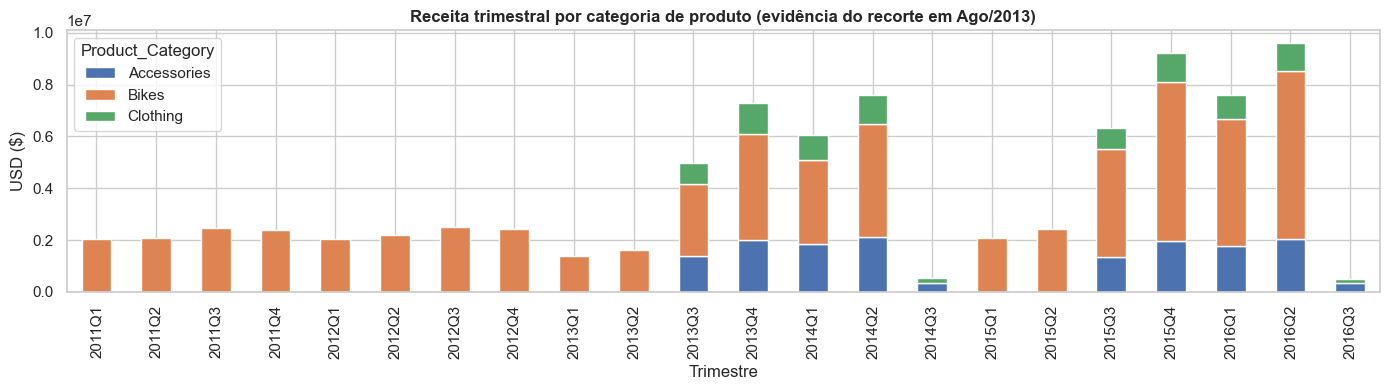

In [3]:
# Agregação Diária com frequência regular (asfreq D)
df_daily_raw = df_raw.groupby('Date').agg({
    'Revenue': 'sum',
    'Order_Quantity': 'sum',
    'Cost': 'sum',
    'Profit': 'sum',
    'Unit_Price': 'mean',
    'Unit_Cost': 'mean'
})

# Auditoria de irregularidades temporais: dias sem nenhuma transação no período de modelagem
dias_modelagem = pd.date_range('2013-08-01', df_daily_raw.index.max(), freq='D')
dias_sem_venda = dias_modelagem.difference(df_daily_raw.index)
print(f'Dias sem nenhuma transação no período de modelagem (preenchidos com 0): {len(dias_sem_venda)} de {len(dias_modelagem)}')

df_daily = df_daily_raw.asfreq('D', fill_value=0)

# Recorte temporal contínuo e homogêneo (01/08/2013 a 31/07/2016)
ts_data = df_daily[df_daily.index >= '2013-08-01'].copy()
series = ts_data[['Revenue']].copy()

print(f'Série Temporal Diária Consolidada: {len(series)} observações diárias contínuas.')
print(f'Intervalo: de {series.index.min().strftime("%d/%m/%Y")} a {series.index.max().strftime("%d/%m/%Y")}')
print(f'Valores nulos na série: {series.isna().sum().sum()}')
display(series.head())

# Evidência do recorte: primeira venda e receita trimestral por categoria de produto
print('\nPrimeira venda registrada por categoria de produto:')
display(df_raw.groupby('Product_Category')['Date'].min().sort_values().to_frame('Primeira venda'))

rev_cat_q = df_raw.pivot_table(index=df_raw['Date'].dt.to_period('Q').astype(str),
                               columns='Product_Category', values='Revenue', aggfunc='sum', fill_value=0)
rev_cat_q.plot(kind='bar', stacked=True, figsize=(14, 4))
plt.title('Receita trimestral por categoria de produto (evidência do recorte em Ago/2013)', fontweight='bold')
plt.ylabel('USD ($)')
plt.xlabel('Trimestre')
plt.tight_layout()
plt.show()

## 4. Análise Visual da Série Temporal

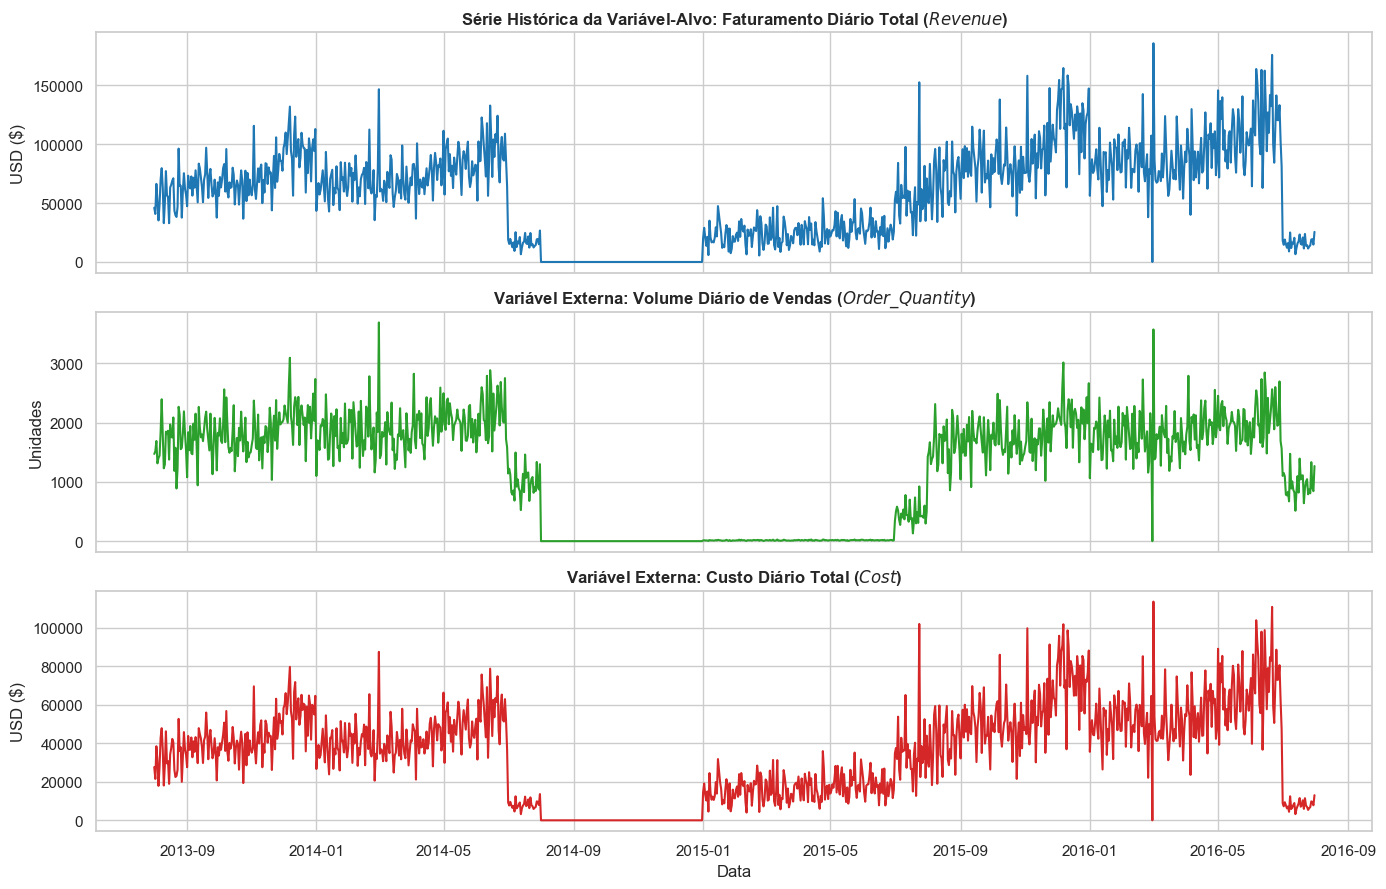

In [4]:
# Visualização da Série Histórica da Variável-Alvo e Exógenas
fig, axes = plt.subplots(3, 1, figsize=(14, 9), sharex=True)

axes[0].plot(ts_data.index, ts_data['Revenue'], color='#1f77b4', lw=1.5)
axes[0].set_title('Série Histórica da Variável-Alvo: Faturamento Diário Total ($Revenue$)', fontweight='bold')
axes[0].set_ylabel('USD ($)')

axes[1].plot(ts_data.index, ts_data['Order_Quantity'], color='#2ca02c', lw=1.5)
axes[1].set_title('Variável Externa: Volume Diário de Vendas ($Order\\_Quantity$)', fontweight='bold')
axes[1].set_ylabel('Unidades')

axes[2].plot(ts_data.index, ts_data['Cost'], color='#d62728', lw=1.5)
axes[2].set_title('Variável Externa: Custo Diário Total ($Cost$)', fontweight='bold')
axes[2].set_ylabel('USD ($)')
axes[2].set_xlabel('Data')

plt.tight_layout()
plt.show()

## 5. Divisão Entre Treino e Teste

Para avaliação fora da amostra (*out-of-sample*), dividimos a série de forma sequencial por uma **data de corte fixa** (`TEST_START = 28/12/2015`, equivalente a 80% / 20% da matriz de features, que começa em 15/08/2013 por causa dos lags). A mesma data de corte é usada em **todas** as seções (baselines, Holt-Winters, SARIMA, Feature Engineering e walk-forward), de modo que todos os modelos sejam avaliados exatamente nas mesmas datas, preservando estritamente a ordem cronológica sem embaralhamento.

In [5]:
TEST_START = pd.Timestamp('2015-12-28')   # primeira data de teste (origem do primeiro walk-forward)

train = series.loc[:TEST_START - pd.Timedelta(days=1)]
test = series.loc[TEST_START:]
H = len(test)

print(f'Tamanho do conjunto de Treino: {len(train)} observações ({train.index.min().date()} a {train.index.max().date()})')
print(f'Tamanho do conjunto de Teste:  {len(test)} observações ({test.index.min().date()} a {test.index.max().date()})')
print(f'Dias de teste: {H} | Horizonte no walk-forward: h = 1 dia (origem diária)')

Tamanho do conjunto de Treino: 879 observações (2013-08-01 a 2015-12-27)
Tamanho do conjunto de Teste:  217 observações (2015-12-28 a 2016-07-31)
Dias de teste: 217 | Horizonte no walk-forward: h = 1 dia (origem diária)


## 6. Decomposição STL e Força dos Componentes

A decomposição **STL (Seasonal and Trend decomposition using Loess)** separa a série temporal $Y_t$ em três componentes aditivos:
$$Y_t = T_t + S_t + R_t$$
Onde:
- $T_t$: Tendência (*Trend*)
- $S_t$: Sazonalidade Semanal ($m=7$)
- $R_t$: Resíduo (*Residual*)

### Força da Sazonalidade e da Tendência
$$F_s = \max\left(0, 1 - \frac{\mathrm{Var}(R_t)}{\mathrm{Var}(S_t + R_t)}\right), \quad F_t = \max\left(0, 1 - \frac{\mathrm{Var}(R_t)}{\mathrm{Var}(T_t + R_t)}\right)$$

Para validar a escolha de $m=7$, comparamos também a força da sazonalidade em outros períodos candidatos (14, 30 e 365 dias). Valores de $F_s$ próximos de zero indicam sazonalidade fraca.

=== MÉTRICAS DE DECOMPOSIÇÃO TEMPORAL (STL NO TREINO) ===
Força da Sazonalidade (Fs): 0.0639 (6.39%) -> sazonalidade fraca
Força da Tendência    (Ft): 0.8587 (85.87%) -> tendência forte


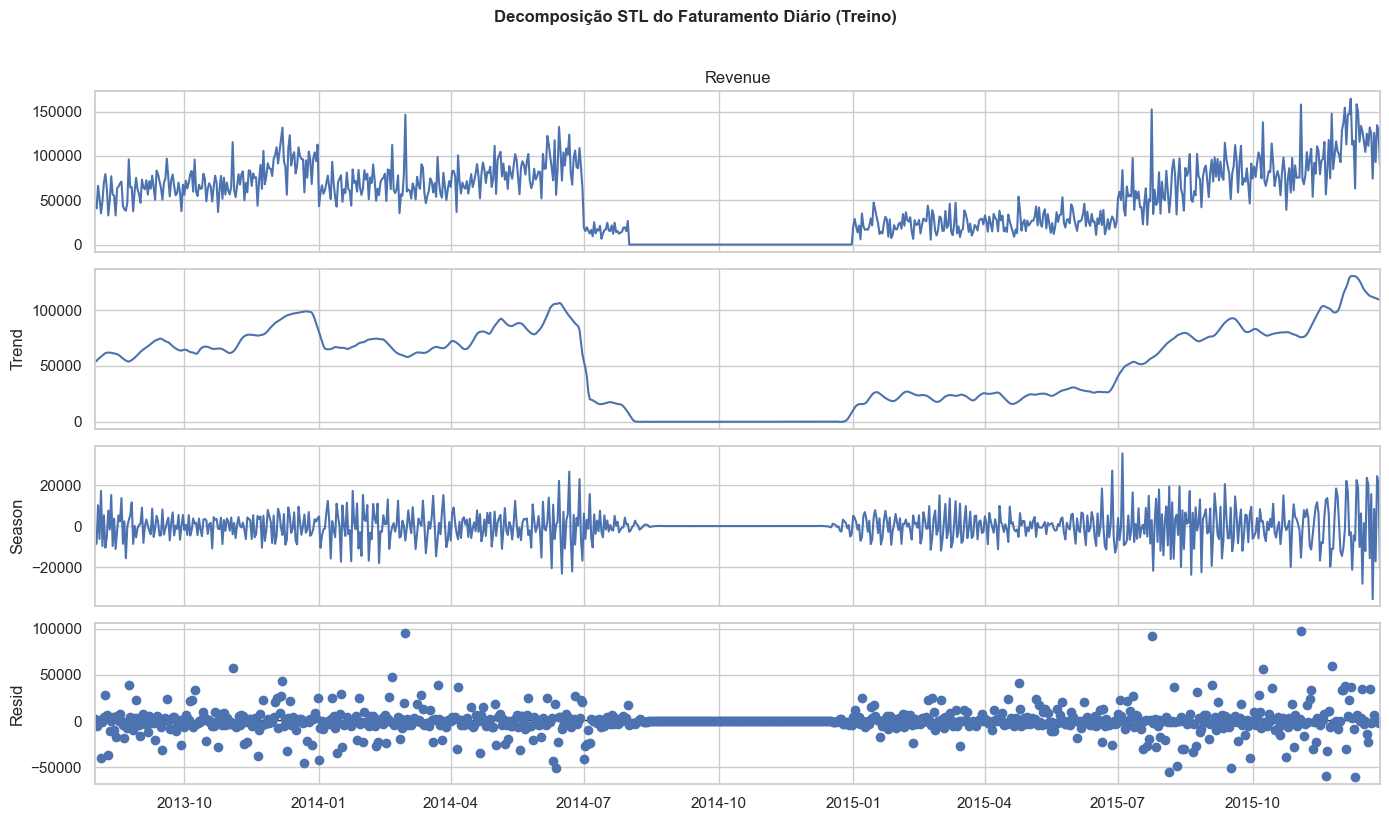


=== FORÇA DA SAZONALIDADE POR PERÍODO CANDIDATO ===


,Período (dias),Fs,Leitura
0,7,0.06,fraca
1,14,0.14,fraca
2,30,0.06,fraca
3,365,0.34,moderada



=== FASES DA TENDÊNCIA (variação trimestral; ±5% = estabilidade) ===


,Tendência (fim do trimestre),Variação (%),Fase
Date,,,
2013Q3,64078.48,NaN,-
2013Q4,84287.50,31.54,crescimento
2014Q1,69970.76,-16.99,queda
2014Q2,60196.93,-13.97,queda
2014Q3,-0.00,-100.00,queda
2014Q4,8408.49,-3139909662.83,queda
2015Q1,25503.22,203.30,crescimento
2015Q2,38214.30,49.84,crescimento
2015Q3,81472.50,113.20,crescimento


In [6]:
m = 7 # Período sazonal semanal
stl = STL(train['Revenue'], period=m, robust=True).fit()

def classifica_forca(v):
    # Critério adotado pelo grupo para a leitura qualitativa (0 = nenhuma, 1 = máxima)
    return 'forte' if v >= 0.6 else ('moderada' if v >= 0.3 else 'fraca')

# Cálculo das métricas quantitativas de Força de Tendência e Sazonalidade
var_resid = np.var(stl.resid)
var_seas_resid = np.var(stl.seasonal + stl.resid)
var_trend_resid = np.var(stl.trend + stl.resid)

fs = max(0.0, 1.0 - (var_resid / var_seas_resid))
ft = max(0.0, 1.0 - (var_resid / var_trend_resid))

print('=== MÉTRICAS DE DECOMPOSIÇÃO TEMPORAL (STL NO TREINO) ===')
print(f'Força da Sazonalidade (Fs): {fs:.4f} ({fs*100:.2f}%) -> sazonalidade {classifica_forca(fs)}')
print(f'Força da Tendência    (Ft): {ft:.4f} ({ft*100:.2f}%) -> tendência {classifica_forca(ft)}')

fig = stl.plot()
fig.set_size_inches(14, 8)
plt.suptitle('Decomposição STL do Faturamento Diário (Treino)', y=1.02, fontweight='bold')
plt.tight_layout()
plt.show()

# Força da sazonalidade para outros períodos candidatos
fs_rows = []
for per in [7, 14, 30, 365]:
    try:
        s_p = STL(train['Revenue'], period=per, robust=True).fit()
        fs_p = max(0.0, 1.0 - np.var(s_p.resid) / np.var(s_p.seasonal + s_p.resid))
        fs_rows.append({'Período (dias)': per, 'Fs': fs_p, 'Leitura': classifica_forca(fs_p)})
    except Exception as e:
        fs_rows.append({'Período (dias)': per, 'Fs': np.nan, 'Leitura': f'não calculável ({type(e).__name__})'})
print('\n=== FORÇA DA SAZONALIDADE POR PERÍODO CANDIDATO ===')
display(pd.DataFrame(fs_rows))

# Leitura da tendência: variação do componente de tendência ao final de cada trimestre
trend_q = stl.trend.groupby(stl.trend.index.to_period('Q')).last()
df_trend_q = pd.DataFrame({'Tendência (fim do trimestre)': trend_q, 'Variação (%)': trend_q.pct_change() * 100})
df_trend_q['Fase'] = np.where(df_trend_q['Variação (%)'] > 5, 'crescimento',
                      np.where(df_trend_q['Variação (%)'] < -5, 'queda', 'estabilidade'))
df_trend_q.loc[df_trend_q['Variação (%)'].isna(), 'Fase'] = '-'
print('\n=== FASES DA TENDÊNCIA (variação trimestral; ±5% = estabilidade) ===')
display(df_trend_q)

## 7. Testes Formais de Estacionariedade

Para avaliar a estacionariedade da série de faturamento, aplicamos os testes estatísticos formais:
1. **ADF (*Augmented Dickey-Fuller*)**: $H_0$: A série possui raiz unitária (não é estacionária). Rejeitar $H_0$ ($p < 0.05$) indica estacionariedade.
2. **KPSS (*Kwiatkowski-Phillips-Schmidt-Shin*)**: $H_0$: A série é estacionária em torno de um nível determinístico. Rejeitar $H_0$ ($p < 0.05$) indica não estacionariedade.
3. **Função de Autocorrelação (ACF)** da série original.

--- TESTE ADF (Treino Original) ---
  ADF Statistic: -1.2773785459237676
  p-value: 0.6394570739715719
  Critical Values 1/5/10%: {'1%': np.float64(-3.4378800537375045), '5%': np.float64(-2.864864011317803), '10%': np.float64(-2.5685399483682003)}

--- TESTE KPSS (Treino Original) ---
  KPSS Statistic: 0.8662464233650613
  p-value: 0.01
  Critical Values 10/5/2.5/1%: {'10%': 0.347, '5%': 0.463, '2.5%': 0.574, '1%': 0.739}


C:\Users\raissacasale-ieg\AppData\Local\Temp\ipykernel_34992\747456890.py:14: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  res = kpss(x.dropna())


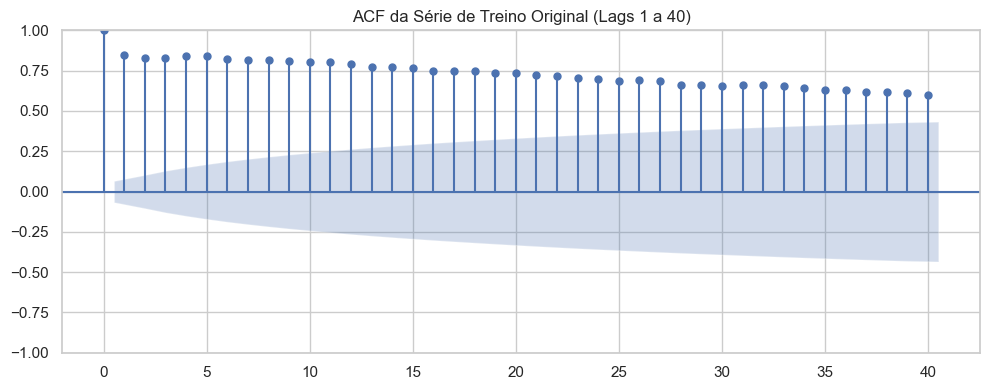

In [7]:
def test_adf(x, name='Série'):
    res = adfuller(x.dropna())
    results = {
        'ADF Statistic': res[0],
        'p-value': res[1],
        'Critical Values 1/5/10%': res[4]
    }
    print(f'--- TESTE ADF ({name}) ---')
    for k, v in results.items():
        print(f'  {k}: {v}')
    return res

def test_kpss(x, name='Série'):
    res = kpss(x.dropna())
    results = {
        'KPSS Statistic': res[0],
        'p-value': res[1],
        'Critical Values 10/5/2.5/1%': res[3]
    }
    print(f'--- TESTE KPSS ({name}) ---')
    for k, v in results.items():
        print(f'  {k}: {v}')
    return res

test_adf(train['Revenue'], name='Treino Original')
print()
test_kpss(train['Revenue'], name='Treino Original')

fig, ax = plt.subplots(figsize=(10, 4))
plot_acf(train['Revenue'], lags=40, ax=ax)
ax.set_title('ACF da Série de Treino Original (Lags 1 a 40)')
plt.tight_layout()
plt.show()

## 8. Diferenciação e Análise de ACF e PACF

Como a série original apresentou evidências de não estacionariedade nos testes ADF (não rejeita $H_0$) e KPSS (rejeita $H_0$) e decaimento persistente na ACF, aplicamos a primeira diferenciação:
$$\Delta Y_t = Y_t - Y_{t-1}$$
Em seguida, avaliamos os gráficos de ACF e PACF para determinar as ordens autorregressivas ($p$) e de médias móveis ($q$).

=== TESTES APÓS PRIMEIRA DIFERENCIAÇÃO (d=1) ===
--- TESTE ADF (Série Diferenciada (d=1)) ---
  ADF Statistic: -17.45992665660755
  p-value: 4.603207661419777e-30
  Critical Values 1/5/10%: {'1%': np.float64(-3.4378800537375045), '5%': np.float64(-2.864864011317803), '10%': np.float64(-2.5685399483682003)}

--- TESTE KPSS (Série Diferenciada (d=1)) ---
  KPSS Statistic: 0.1343124851904826
  p-value: 0.1
  Critical Values 10/5/2.5/1%: {'10%': 0.347, '5%': 0.463, '2.5%': 0.574, '1%': 0.739}


C:\Users\raissacasale-ieg\AppData\Local\Temp\ipykernel_34992\747456890.py:14: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  res = kpss(x.dropna())


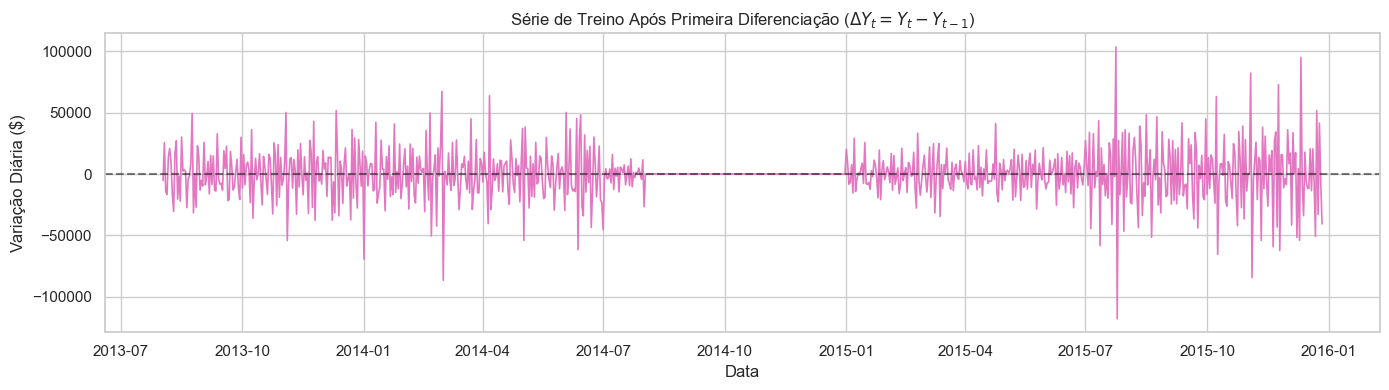

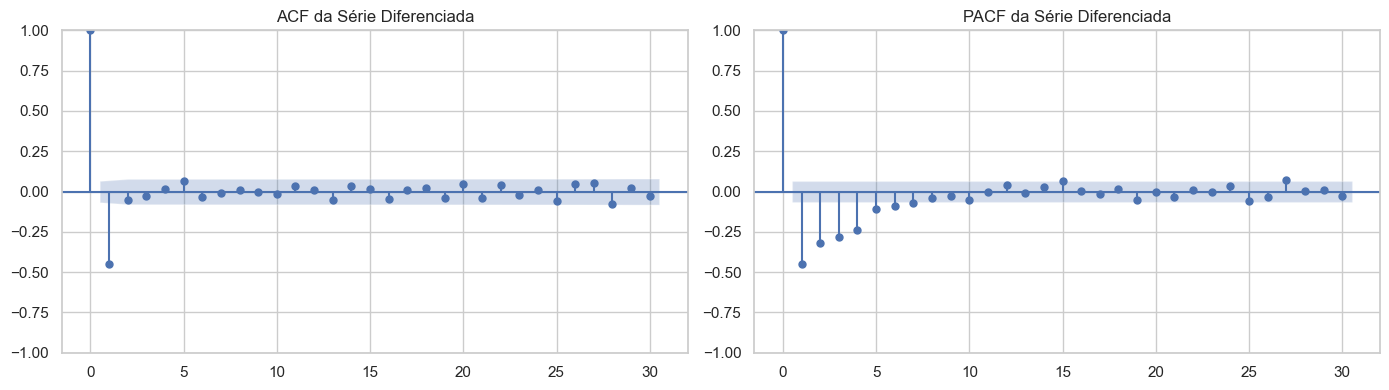

In [8]:
diff_train = train['Revenue'].diff(1).dropna()

print('=== TESTES APÓS PRIMEIRA DIFERENCIAÇÃO (d=1) ===')
test_adf(diff_train, name='Série Diferenciada (d=1)')
print()
test_kpss(diff_train, name='Série Diferenciada (d=1)')

# Plot da série diferenciada
plt.figure(figsize=(14, 4))
plt.plot(diff_train.index, diff_train.values, color='#e377c2', lw=1.2)
plt.title(r'Série de Treino Após Primeira Diferenciação ($\Delta Y_t = Y_t - Y_{t-1}$)')
plt.xlabel('Data')
plt.ylabel('Variação Diária ($)')
plt.axhline(0, color='black', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# Correlogramas ACF e PACF
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_acf(diff_train, lags=30, ax=axes[0], title='ACF da Série Diferenciada')
plot_pacf(diff_train, lags=30, ax=axes[1], title='PACF da Série Diferenciada')
plt.tight_layout()
plt.show()

## 9. Construção dos Modelos Base (*Baselines*)

Implementamos os modelos base com ajuste de hiperparâmetros no treino e avaliação no teste. Cada previsão é de 1 passo à frente com o histórico real até $t-1$, o mesmo protocolo do walk-forward, e o conjunto de teste é **exatamente o mesmo** da Seção 14:
1. **Média Móvel (Rolling Mean)**: Otimização da janela $k \in \{1, 2, 3, 5, 7, 14, 28\}$.
2. **Média Acumulada (Expanding Mean)**: $\hat{Y}_t = \frac{1}{t-1} \sum_{i=1}^{t-1} Y_i$.
3. **EMA (Exponential Moving Average)**: Otimização do coeficiente de suavização $\alpha \in [0.1, 0.9]$.
4. **Seasonal Naive**: Otimização do lag sazonal $s \in \{1, 2, 3, 7, 14, 28\}$.
5. **Delta**: Otimização da janela de tendência $j \in \{1, 2, 3, 7, 14, 28\}$.

O parâmetro de cada baseline é escolhido pelo **MAE no treino**; o MAE no teste é apenas reportado.

In [9]:
y = series['Revenue']
y_train = train['Revenue']
y_test = test['Revenue']

sumario = {}

# 1. Média Móvel
ks = [1, 2, 3, 5, 7, 14, 28]
k_max = max(ks)
mm_detalhado = {}
resultado_mm = []

for k in ks:
    pred_full = y.rolling(window=k).mean().shift(1)
    mm_detalhado[f'mm_{k}'] = pred_full
    mae_train = mean_absolute_error(y_train.iloc[k_max:], pred_full.loc[y_train.index].iloc[k_max:])
    mae_test = mean_absolute_error(y_test, pred_full.loc[y_test.index])
    resultado_mm.append({'k': k, 'MAE_train': mae_train, 'MAE_test': mae_test})

df_res_mm = pd.DataFrame(resultado_mm)
best_k = int(df_res_mm.loc[df_res_mm['MAE_train'].idxmin(), 'k'])
sumario['Média Móvel'] = {
    'Parâmetro': f'k={best_k}',
    'MAE_train': df_res_mm.loc[df_res_mm['MAE_train'].idxmin(), 'MAE_train'],
    'MAE_test': df_res_mm.loc[df_res_mm['MAE_train'].idxmin(), 'MAE_test']
}

# 2. Média Acumulada
pred_exp = y.expanding().mean().shift(1)
sumario['Média Acumulada'] = {
    'Parâmetro': '-',
    'MAE_train': mean_absolute_error(y_train.iloc[1:], pred_exp.loc[y_train.index].iloc[1:]),
    'MAE_test': mean_absolute_error(y_test, pred_exp.loc[y_test.index])
}

# 3. EMA
alphas = np.round(np.arange(0.1, 1.0, 0.1), 2)
resultado_ema = []
for alpha in alphas:
    pred_ema = y.ewm(alpha=alpha, adjust=False).mean().shift(1)
    mae_train = mean_absolute_error(y_train.iloc[1:], pred_ema.loc[y_train.index].iloc[1:])
    mae_test = mean_absolute_error(y_test, pred_ema.loc[y_test.index])
    resultado_ema.append({'Alpha': alpha, 'MAE_train': mae_train, 'MAE_test': mae_test})

df_res_ema = pd.DataFrame(resultado_ema)
best_alpha = df_res_ema.loc[df_res_ema['MAE_train'].idxmin(), 'Alpha']
sumario['EMA'] = {
    'Parâmetro': f'alpha={best_alpha}',
    'MAE_train': df_res_ema.loc[df_res_ema['MAE_train'].idxmin(), 'MAE_train'],
    'MAE_test': df_res_ema.loc[df_res_ema['MAE_train'].idxmin(), 'MAE_test']
}

# 4. Seasonal Naive
ss = [1, 2, 3, 7, 14, 28]
s_max = max(ss)
resultado_sn = []
for s in ss:
    pred_sn = y.shift(s)
    mae_train = mean_absolute_error(y_train.iloc[s_max:], pred_sn.loc[y_train.index].iloc[s_max:])
    mae_test = mean_absolute_error(y_test, pred_sn.loc[y_test.index])
    resultado_sn.append({'Sazonalidade': s, 'MAE_train': mae_train, 'MAE_test': mae_test})

df_res_sn = pd.DataFrame(resultado_sn)
best_s = int(df_res_sn.loc[df_res_sn['MAE_train'].idxmin(), 'Sazonalidade'])
sumario['Seasonal Naive'] = {
    'Parâmetro': f's={best_s}',
    'MAE_train': df_res_sn.loc[df_res_sn['MAE_train'].idxmin(), 'MAE_train'],
    'MAE_test': df_res_sn.loc[df_res_sn['MAE_train'].idxmin(), 'MAE_test']
}

# 5. Delta
janelas = [1, 2, 3, 7, 14, 28]
j_max = max(janelas)
resultado_delta = []
for j in janelas:
    pred_delta = y.shift(1) + (y.shift(1) - y.shift(1 + j)) / j
    mae_train = mean_absolute_error(y_train.iloc[1+j_max:], pred_delta.loc[y_train.index].iloc[1+j_max:])
    mae_test = mean_absolute_error(y_test, pred_delta.loc[y_test.index])
    resultado_delta.append({'Janela': j, 'MAE_train': mae_train, 'MAE_test': mae_test})

df_res_delta = pd.DataFrame(resultado_delta)
best_j = int(df_res_delta.loc[df_res_delta['MAE_train'].idxmin(), 'Janela'])
sumario['Delta'] = {
    'Parâmetro': f'j={best_j}',
    'MAE_train': df_res_delta.loc[df_res_delta['MAE_train'].idxmin(), 'MAE_train'],
    'MAE_test': df_res_delta.loc[df_res_delta['MAE_train'].idxmin(), 'MAE_test']
}

df_baselines = pd.DataFrame.from_dict(sumario, orient='index').reset_index().rename(columns={'index': 'Modelo'})
print('=== DESEMPENHO DOS MODELOS BASE (BASELINES) ===')
display(df_baselines.sort_values(by='MAE_test'))

=== DESEMPENHO DOS MODELOS BASE (BASELINES) ===


,Modelo,Parâmetro,MAE_train,MAE_test
2,EMA,alpha=0.2,10820.85,18883.79
0,Média Móvel,k=7,10781.36,18937.67
3,Seasonal Naive,s=1,13856.41,22812.85
4,Delta,j=28,14166.36,23379.55
1,Média Acumulada,-,29874.18,41870.79


## 10. Suavização Exponencial e Modelo Holt-Winters

Comparamos a Suavização Exponencial Simples (**SES**, referência sem tendência e sem sazonalidade) com o **Holt-Winters**. A configuração do Holt-Winters é escolhida por **busca em grade no treino**, sem usar o teste, pelo critério **BIC**:
- **Tendência**: ausente, aditiva ou aditiva amortecida (*damped*);
- **Sazonalidade**: aditiva ou multiplicativa;
- **Período sazonal**: $m \in \{7, 30\}$;
- **Parâmetros de suavização** ($\alpha$, $\beta$, $\gamma$, $\phi$): estimados por máxima verossimilhança em cada ajuste.

O MAE de teste estático ($H$ passos) é exibido apenas de forma descritiva; o MAE oficial é o do walk-forward (Seção 15).

=== BUSCA EM GRADE DO HOLT-WINTERS (ordenada por BIC, somente treino) ===


,trend,damped_trend,seasonal,seasonal_periods,AIC,BIC,Convergiu,MAE Treino
0,None,False,add,7,17057.98,17100.99,False,11166.14
1,add,False,add,7,17063.72,17116.29,False,11162.92
2,add,True,add,7,17065.85,17123.20,False,11148.11
3,None,False,add,30,17147.80,17300.73,False,11750.45
4,add,False,add,30,17156.59,17319.07,False,11843.02
5,add,True,add,30,17154.19,17321.45,False,11719.58


Configuração selecionada: {'trend': None, 'damped_trend': False, 'seasonal': 'add', 'seasonal_periods': 7} (convergiu: False)

=== COMPARAÇÃO DE MODELOS DE SUAVIZAÇÃO EXPONENCIAL (HOLT-WINTERS) ===


,Modelo,AIC,BIC,MAE Treino,MAE Teste (H passos)
0,Suavização Exponencial Simples (SES),17027.24,17036.80,10809.13,36374.39
1,"Holt-Winters (tend=None, amort=False, sazon=ad...",17057.98,17100.99,11166.14,36176.78


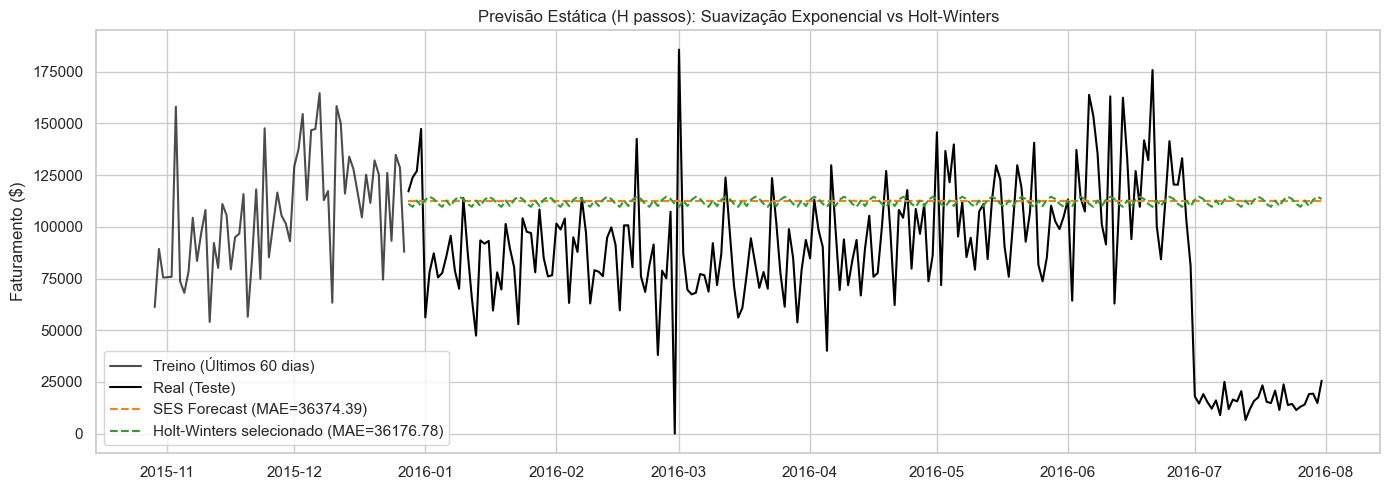

In [10]:
def fit_hw(y_hist, cfg):
    """Ajusta o Holt-Winters com a configuração `cfg`; mesma função usada no walk-forward."""
    return ExponentialSmoothing(y_hist, initialization_method='estimated', **cfg).fit()

# 1. Suavização Exponencial Simples (SES) - referência
with warnings.catch_warnings():
    warnings.simplefilter('ignore')
    ses_model = ExponentialSmoothing(train['Revenue'], trend=None, seasonal=None, initialization_method='estimated').fit()
fc_ses = ses_model.forecast(H)
mae_ses_train = mean_absolute_error(train['Revenue'], ses_model.fittedvalues)
mae_ses_test = mean_absolute_error(test['Revenue'], fc_ses)

# 2. Busca em grade do Holt-Winters (seleção por BIC no treino)
hw_results = []
for trend, damped in [(None, False), ('add', False), ('add', True)]:
    for seasonal in ['add', 'mul']:
        for sp in [7, 30]:
            cfg = {'trend': trend, 'damped_trend': damped, 'seasonal': seasonal, 'seasonal_periods': sp}
            try:
                with warnings.catch_warnings(record=True) as wl:
                    warnings.simplefilter('always')
                    fit_i = fit_hw(train['Revenue'], cfg)
                convergiu = not any('Convergence' in w.category.__name__ for w in wl)
                if np.isfinite(fit_i.bic):
                    hw_results.append({'cfg': cfg, 'AIC': fit_i.aic, 'BIC': fit_i.bic, 'Convergiu': convergiu,
                                       'MAE Treino': mean_absolute_error(train['Revenue'], fit_i.fittedvalues)})
            except Exception:
                continue

hw_results.sort(key=lambda r: r['BIC'])
best_hw_cfg = hw_results[0]['cfg']
df_hw_grid = pd.DataFrame([{**r['cfg'], 'AIC': r['AIC'], 'BIC': r['BIC'], 'Convergiu': r['Convergiu'], 'MAE Treino': r['MAE Treino']} for r in hw_results])
print('=== BUSCA EM GRADE DO HOLT-WINTERS (ordenada por BIC, somente treino) ===')
display(df_hw_grid)
print(f'Configuração selecionada: {best_hw_cfg} (convergiu: {hw_results[0]["Convergiu"]})')

with warnings.catch_warnings():
    warnings.simplefilter('ignore')
    hw_best_model = fit_hw(train['Revenue'], best_hw_cfg)
fc_hw = hw_best_model.forecast(H)
mae_hw_train = mean_absolute_error(train['Revenue'], hw_best_model.fittedvalues)
mae_hw_test = mean_absolute_error(test['Revenue'], fc_hw)
hw_label = (f"Holt-Winters (tend={best_hw_cfg['trend']}, amort={best_hw_cfg['damped_trend']}, "
            f"sazon={best_hw_cfg['seasonal']}, m={best_hw_cfg['seasonal_periods']})")

df_hw_comp = pd.DataFrame([
    {'Modelo': 'Suavização Exponencial Simples (SES)', 'AIC': ses_model.aic, 'BIC': ses_model.bic, 'MAE Treino': mae_ses_train, 'MAE Teste (H passos)': mae_ses_test},
    {'Modelo': hw_label, 'AIC': hw_best_model.aic, 'BIC': hw_best_model.bic, 'MAE Treino': mae_hw_train, 'MAE Teste (H passos)': mae_hw_test}
])

print('\n=== COMPARAÇÃO DE MODELOS DE SUAVIZAÇÃO EXPONENCIAL (HOLT-WINTERS) ===')
display(df_hw_comp)

# Plot das Previsões Estáticas (descritivo)
plt.figure(figsize=(14, 5))
plt.plot(train.index[-60:], train['Revenue'].iloc[-60:], label='Treino (Últimos 60 dias)', color='black', alpha=0.7)
plt.plot(test.index, test['Revenue'], label='Real (Teste)', color='black', lw=1.5)
plt.plot(test.index, fc_ses, label=f'SES Forecast (MAE={mae_ses_test:.2f})', linestyle='--', color='#ff7f0e')
plt.plot(test.index, fc_hw, label=f'Holt-Winters selecionado (MAE={mae_hw_test:.2f})', linestyle='--', color='#2ca02c')
plt.title('Previsão Estática (H passos): Suavização Exponencial vs Holt-Winters')
plt.ylabel('Faturamento ($)')
plt.legend()
plt.tight_layout()
plt.show()

## 11. Definição e Otimização dos Parâmetros do SARIMA

Realizamos uma busca em grade estruturada (*Grid Search*) testando combinações de ordens $(p, d, q) \times (P, D, Q)_7$ sobre o conjunto de treino, selecionando a melhor ordem pelo critério **BIC** (princípio da parcimônia). Observações:
- O alvo é dividido por 1.000 (`SCALE`) para estabilidade numérica da otimização; isso desloca o BIC por uma constante e **não altera a seleção**.
- O modelo escolhido é reajustado com `cov_type='approx'` (Hessiana numérica), porque a covariância padrão (OPG) pode gerar erro-padrão degenerado para `sigma2` e p-valores pouco confiáveis.
- AIC/BIC não são estritamente comparáveis entre modelos com ordens de diferenciação ($d+D$) diferentes; a comparação entre eles deve ser lida com cautela.
- Este SARIMA (sem exógenas) é a referência de ordem. A ordem do **SARIMAX** com variáveis exógenas é reotimizada na Seção 13.

In [11]:
SCALE = 1000.0   # o alvo é modelado em milhares de US$ para estabilizar a otimização do SARIMAX

p_range = [0, 1, 2]
d_range = [1]
q_range = [0, 1, 2]
P_range = [0, 1]
D_range = [0, 1]
Q_range = [0, 1]
m = 7

orders = list(itertools.product(p_range, d_range, q_range))
seasonal_orders = list(itertools.product(P_range, D_range, Q_range))

results_sarima = []
best_sarima_model = None
best_sarima_bic = float('inf')

for order in orders:
    for s_order in seasonal_orders:
        try:
            m_fit = SARIMAX(
                train['Revenue'] / SCALE,
                order=order,
                seasonal_order=(*s_order, m),
                enforce_stationarity=False,
                enforce_invertibility=False
            ).fit(disp=False, maxiter=200)

            results_sarima.append({
                'Modelo': f'SARIMA{order}{(*s_order, m)}',
                'BIC': m_fit.bic,
                'AIC': m_fit.aic,
                'fitted_model': m_fit
            })

            if m_fit.bic < best_sarima_bic:
                best_sarima_bic = m_fit.bic
                best_sarima_model = m_fit
                best_sarima_spec = (order, (*s_order, m))
        except Exception:
            continue

df_sarima_grid = pd.DataFrame(results_sarima).sort_values(by='BIC').reset_index(drop=True)
print('=== TOP 10 MODELOS SARIMA SELECIONADOS PELO CRITÉRIO BIC (alvo em milhares de US$) ===')
display(df_sarima_grid[['Modelo', 'BIC', 'AIC']].head(10))
print(f'\nMelhor Modelo SARIMA Selecionado: {df_sarima_grid.loc[0, "Modelo"]} (BIC={best_sarima_bic:.2f})')

# Reajuste do modelo escolhido com covariância numérica (cov_type='approx'): a covariância padrão (OPG)
# costuma produzir erro-padrão degenerado para sigma2, invalidando os p-valores do summary.
best_sarima_model = SARIMAX(train['Revenue'] / SCALE, order=best_sarima_spec[0], seasonal_order=best_sarima_spec[1],
                            enforce_stationarity=False, enforce_invertibility=False).fit(disp=False, maxiter=200, cov_type='approx')
print(best_sarima_model.summary())

=== TOP 10 MODELOS SARIMA SELECIONADOS PELO CRITÉRIO BIC (alvo em milhares de US$) ===


,Modelo,BIC,AIC
0,"SARIMA(0, 1, 2)(0, 1, 1, 7)",7272.68,7253.65
1,"SARIMA(1, 1, 2)(0, 1, 1, 7)",7273.16,7249.36
2,"SARIMA(0, 1, 1)(0, 1, 1, 7)",7273.91,7259.63
3,"SARIMA(2, 1, 2)(0, 1, 1, 7)",7274.88,7246.33
4,"SARIMA(0, 1, 2)(1, 1, 1, 7)",7279.43,7255.64
5,"SARIMA(1, 1, 2)(1, 1, 1, 7)",7279.86,7251.31
6,"SARIMA(1, 1, 1)(0, 1, 1, 7)",7280.61,7261.58
7,"SARIMA(0, 1, 1)(1, 1, 1, 7)",7280.66,7261.63
8,"SARIMA(2, 1, 2)(1, 1, 1, 7)",7281.55,7248.24
9,"SARIMA(2, 1, 1)(0, 1, 1, 7)",7283.26,7259.46



Melhor Modelo SARIMA Selecionado: SARIMA(0, 1, 2)(0, 1, 1, 7) (BIC=7272.68)
                                      SARIMAX Results                                      
Dep. Variable:                             Revenue   No. Observations:                  879
Model:             SARIMAX(0, 1, 2)x(0, 1, [1], 7)   Log Likelihood               -3622.823
Date:                             Tue, 06 Oct 2026   AIC                           7253.646
Time:                                     08:29:26   BIC                           7272.679
Sample:                                 08-01-2013   HQIC                          7260.932
                                      - 12-27-2015                                         
Covariance Type:                            approx                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1         -0.8085      0.

## 12. Feature Engineering e Prevenção de Vazamento de Dados (*Data Leakage*)

Para os modelos tabulares e redes neurais que utilizam variáveis externas, construímos a matriz de features garantindo que toda transformação utilize apenas informações disponíveis na origem da previsão (ver tabela de disponibilidade na Seção 2):
1. **Lags do Alvo**: $Y_{t-1}, Y_{t-2}, Y_{t-3}, Y_{t-7}, Y_{t-14}$.
2. **Estatísticas Móveis Defasadas**: médias e desvios padrão móveis e uma média exponencial (EMA, com o $\alpha$ escolhido no treino na Seção 9), todos calculados com `shift(1)` (sem vazamento).
3. **Lags de Variáveis Derivadas das Vendas**: $Cost_{t-1}, Cost_{t-7}, Order\_Quantity_{t-1}, Order\_Quantity_{t-7}$.
4. **Variáveis de Calendário e Cíclicas** (conhecidas antecipadamente): senos e cossenos do dia da semana e do mês, indicador de final de semana, **feriado federal dos EUA** e indicadores de início e fim de mês.
5. **Tratamento de ausentes**: os lags e janelas geram `NaN` nas primeiras linhas (aquecimento de 14 dias), que são **removidas** (`dropna`), pois imputar valores usaria informação inexistente na origem.

In [12]:
# Construção da Matriz de Features Tabular
df_features = pd.DataFrame(index=ts_data.index)
df_features['Revenue'] = ts_data['Revenue']

# 1. Lags do Alvo
for lag in [1, 2, 3, 7, 14]:
    df_features[f'target_lag_{lag}'] = ts_data['Revenue'].shift(lag)

# 2. Janelas Móveis (sem vazamento usando shift 1)
df_features['roll_mean_7'] = ts_data['Revenue'].shift(1).rolling(7).mean()
df_features['roll_std_7'] = ts_data['Revenue'].shift(1).rolling(7).std()
df_features['roll_mean_14'] = ts_data['Revenue'].shift(1).rolling(14).mean()
df_features['ewm_mean'] = ts_data['Revenue'].shift(1).ewm(alpha=float(best_alpha), adjust=False).mean()

# 3. Lags de Variáveis derivadas das vendas (só valores passados)
for lag in [1, 7]:
    df_features[f'cost_lag_{lag}'] = ts_data['Cost'].shift(lag)
    df_features[f'qty_lag_{lag}'] = ts_data['Order_Quantity'].shift(lag)

# 4. Features de Calendário (conhecidas antecipadamente)
df_features['dayofweek'] = ts_data.index.dayofweek
df_features['day'] = ts_data.index.day
df_features['month'] = ts_data.index.month
df_features['is_weekend'] = ts_data.index.dayofweek.isin([5, 6]).astype(int)
us_holidays = USFederalHolidayCalendar().holidays(start=ts_data.index.min(), end=ts_data.index.max())
df_features['is_holiday_us'] = ts_data.index.isin(us_holidays).astype(int)
df_features['is_month_start'] = ts_data.index.is_month_start.astype(int)
df_features['is_month_end'] = ts_data.index.is_month_end.astype(int)

# 5. Encoding Cíclico
df_features['dow_sin'] = np.sin(2 * np.pi * df_features['dayofweek'] / 7)
df_features['dow_cos'] = np.cos(2 * np.pi * df_features['dayofweek'] / 7)
df_features['month_sin'] = np.sin(2 * np.pi * df_features['month'] / 12)
df_features['month_cos'] = np.cos(2 * np.pi * df_features['month'] / 12)

# Eliminação dos NaNs gerados pelos lags (aquecimento) e restauração da frequência diária
n_antes = len(df_features)
df_features = df_features.dropna().asfreq('D')
assert not df_features.isna().any().any(), 'A matriz de features não deve conter NaN.'
print(f'Linhas removidas pelo aquecimento dos lags/janelas: {n_antes - len(df_features)}')

feature_columns = [c for c in df_features.columns if c != 'Revenue']
print(f'Matriz de modelagem final: {df_features.shape[0]} amostras x {len(feature_columns)} features explicativas.')
print('Features criadas:', feature_columns)
display(df_features.head())

Linhas removidas pelo aquecimento dos lags/janelas: 14
Matriz de modelagem final: 1082 amostras x 24 features explicativas.
Features criadas: ['target_lag_1', 'target_lag_2', 'target_lag_3', 'target_lag_7', 'target_lag_14', 'roll_mean_7', 'roll_std_7', 'roll_mean_14', 'ewm_mean', 'cost_lag_1', 'qty_lag_1', 'cost_lag_7', 'qty_lag_7', 'dayofweek', 'day', 'month', 'is_weekend', 'is_holiday_us', 'is_month_start', 'is_month_end', 'dow_sin', 'dow_cos', 'month_sin', 'month_cos']


,Revenue,target_lag_1,target_lag_2,target_lag_3,target_lag_7,target_lag_14,roll_mean_7,roll_std_7,roll_mean_14,ewm_mean,cost_lag_1,qty_lag_1,cost_lag_7,qty_lag_7,dayofweek,day,month,is_weekend,is_holiday_us,is_month_start,is_month_end,dow_sin,dow_cos,month_sin,month_cos
Date,,,,,,,,,,,,,,,,,,,,,,,,,
2013-08-15,32936,55054.00,56666.00,77153.00,79638.00,46095.00,59285.71,16093.53,55302.86,56983.97,30769.00,1862.00,47801.00,2393.00,3,15,8,0,0,0,0,0.43,-0.90,-0.87,-0.50
2013-08-16,63156,32936.00,55054.00,56666.00,63475.00,40768.00,52614.00,15929.63,54362.93,52174.38,18918.00,1375.00,36924.00,1811.00,4,16,8,0,0,0,0,-0.43,-0.90,-0.87,-0.50
2013-08-17,65624,63156.00,32936.00,55054.00,32961.00,66315.00,52568.43,15893.80,55962.07,54370.70,34175.00,1968.00,18050.00,1229.00,5,17,8,1,0,0,0,-0.97,-0.22,-0.87,-0.50
2013-08-18,69035,65624.00,63156.00,32936.00,50053.00,51932.00,57234.57,13839.94,55912.71,56621.36,37458.00,1756.00,28672.00,1293.00,6,18,8,1,0,0,0,-0.78,0.62,-0.87,-0.50
2013-08-19,71071,69035.00,65624.00,63156.00,77153.00,35271.00,59946.29,14056.22,57134.36,59104.09,42249.00,1749.00,46182.00,1847.00,0,19,8,0,0,0,0,0.00,1.00,-0.87,-0.50


## 13. Protocolo de Validação Walk-Forward e Otimização de Hiperparâmetros

### 🔁 Metodologia Walk-Forward (Janela Expansiva *Out-of-Sample*)
- **Origem e horizonte**: a cada dia $t$ do teste (28/12/2015 a 31/07/2016) cada modelo prevê o dia $t$ com informação até $t-1$ (horizonte $h=1$ dia). Depois, o valor real é incorporado ao histórico.
- **Mesmos dados para os 4 modelos**: mesmas origens, mesmo horizonte e mesmo conjunto de teste.
- **Atualização**: Random Forest, MLP e os parâmetros do SARIMAX são reestimados a cada 14 dias (janela expansiva). No SARIMAX o estado é atualizado diariamente com a observação real, sem reestimar os parâmetros. O Holt-Winters, por ser leve, é reajustado a cada origem diária.
- **Hiperparâmetros**: selecionados **somente no treino** (validação cruzada temporal `TimeSeriesSplit`) e mantidos **fixos** durante todo o teste.

### 🔎 Estratégias de Otimização
| Modelo | Espaço de busca | Método |
|---|---|---|
| Holt-Winters | tendência, amortecimento, tipo e período sazonal | grade + BIC (Seção 10) |
| SARIMAX | $p,q\in\{0,1,2\}$, $d=1$, $P,Q\in\{0,1\}$, $D=0$, $m=7$, com exógenas | grade + BIC |
| Random Forest | `n_estimators`, `max_depth`, `min_samples_split`, `min_samples_leaf`, `max_features` | busca aleatória (40 sorteios) + `TimeSeriesSplit` (MAE) |
| MLP Regressor | camadas ocultas, `alpha`, `learning_rate_init` | busca aleatória (24 sorteios) + `TimeSeriesSplit` (MAE) |

In [13]:
# Divisão Temporal (mesma data de corte da Seção 5, preservando a frequência diária)
train_df = df_features.loc[:TEST_START - pd.Timedelta(days=1)]
test_df = df_features.loc[TEST_START:]
assert (test_df.index == test.index).all(), 'O teste do walk-forward deve coincidir com o teste das demais seções.'

print(f'Observações de Treino Inicial: {len(train_df)} ({train_df.index.min().date()} a {train_df.index.max().date()})')
print(f'Observações de Teste Walk-Forward: {len(test_df)} ({test_df.index.min().date()} a {test_df.index.max().date()})')

tscv = TimeSeriesSplit(n_splits=3)
print('\n--- OTIMIZAÇÃO DE HIPERPARÂMETROS (somente treino) ---')

# 1. Random Forest: busca aleatória com TimeSeriesSplit
rf_param_space = {
    'n_estimators': [100, 200, 300],
    'max_depth': [4, 6, 10, None],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 4, 8],
    'max_features': [0.3, 0.5, 0.7, 1.0]
}
rf_search = RandomizedSearchCV(RandomForestRegressor(random_state=42), rf_param_space, n_iter=40, cv=tscv,
                               scoring='neg_mean_absolute_error', n_jobs=-1, random_state=42)
rf_search.fit(train_df[feature_columns], train_df['Revenue'])
best_rf_params = rf_search.best_params_
print('Melhores parâmetros Random Forest:', best_rf_params)
print(f'MAE médio na validação cruzada temporal: {-rf_search.best_score_:.2f}')
rf_cv_top = pd.DataFrame(rf_search.cv_results_).sort_values('rank_test_score').head(5)
display(rf_cv_top[['params', 'mean_test_score', 'std_test_score']].assign(MAE_CV=lambda d: -d['mean_test_score']).drop(columns='mean_test_score'))

# 2. MLP Regressor (Rede Neural Artificial - Grupo 4)
# Pipeline: X padronizado + ALVO padronizado (TransformedTargetRegressor). O alvo na escala de 10^4-10^5
# sem padronização faz a rede subajustar; as previsões voltam automaticamente para US$.
def make_mlp(params, seed):
    return TransformedTargetRegressor(
        regressor=Pipeline([
            ('scaler', StandardScaler()),
            ('mlp', MLPRegressor(activation='relu', max_iter=1000, early_stopping=False, random_state=seed, **params))
        ]),
        transformer=StandardScaler()
    )

mlp_param_space = {
    'regressor__mlp__hidden_layer_sizes': [(32, 16), (64, 32), (100,), (64,)],
    'regressor__mlp__alpha': [0.001, 0.01, 0.1, 1.0],
    'regressor__mlp__learning_rate_init': [0.001, 0.005, 0.01]
}
mlp_search = RandomizedSearchCV(make_mlp({}, 42), mlp_param_space, n_iter=24, cv=tscv,
                                scoring='neg_mean_absolute_error', n_jobs=-1, random_state=42)
mlp_search.fit(train_df[feature_columns], train_df['Revenue'])
best_mlp_params = {k.replace('regressor__mlp__', ''): v for k, v in mlp_search.best_params_.items()}
print('Melhores parâmetros MLP Regressor (Rede Neural):', best_mlp_params)
print(f'MAE médio na validação cruzada temporal: {-mlp_search.best_score_:.2f}')
mlp_cv_top = pd.DataFrame(mlp_search.cv_results_).sort_values('rank_test_score').head(5)
display(mlp_cv_top[['params', 'mean_test_score', 'std_test_score']].assign(MAE_CV=lambda d: -d['mean_test_score']).drop(columns='mean_test_score'))

# O MLP é estocástico (inicialização aleatória): o modelo final é a MÉDIA de N_SEEDS redes com sementes distintas.
N_SEEDS = 5

class MLPSeedEnsemble(BaseEstimator, RegressorMixin):
    def __init__(self, params=None, n_seeds=5):
        self.params = params
        self.n_seeds = n_seeds

    def fit(self, X, y):
        self.models_ = [make_mlp(self.params or {}, seed).fit(X, y) for seed in range(self.n_seeds)]
        return self

    def predict(self, X):
        return np.mean([mdl.predict(X) for mdl in self.models_], axis=0)

# 3. SARIMAX com variáveis exógenas: busca em grade por BIC no treino
sarimax_exog_cols = ['dow_sin', 'dow_cos', 'is_weekend', 'is_holiday_us', 'cost_lag_1', 'qty_lag_1']

def sx_exog(df):
    """Exógenas do SARIMAX; custo e quantidade em milhares, mesma escala do alvo."""
    X = df[sarimax_exog_cols].copy()
    for c in ['cost_lag_1', 'qty_lag_1']:
        X[c] = X[c] / SCALE
    return X

sarimax_grid = []
for order in itertools.product([0, 1, 2], [1], [0, 1, 2]):
    for s_order in itertools.product([0, 1], [0], [0, 1]):
        try:
            fit_sx = SARIMAX(train_df['Revenue'] / SCALE, exog=sx_exog(train_df), order=order,
                             seasonal_order=(*s_order, 7), enforce_stationarity=False,
                             enforce_invertibility=False).fit(disp=False, maxiter=200)
            sarimax_grid.append({'order': order, 'seasonal_order': (*s_order, 7), 'BIC': fit_sx.bic, 'AIC': fit_sx.aic})
        except Exception:
            continue
df_sarimax_grid = pd.DataFrame(sarimax_grid).sort_values('BIC').reset_index(drop=True)
best_sarimax_order = tuple(df_sarimax_grid.loc[0, 'order'])
best_sarimax_seasonal = tuple(df_sarimax_grid.loc[0, 'seasonal_order'])
print(f'\nMelhor SARIMAX com exógenas (BIC): order={best_sarimax_order}, seasonal_order={best_sarimax_seasonal}')
display(df_sarimax_grid.head(5))

def fit_sarimax(y_hist, X_hist, cov_type='opg'):
    return SARIMAX(y_hist / SCALE, exog=sx_exog(X_hist), order=best_sarimax_order,
                   seasonal_order=best_sarimax_seasonal, enforce_stationarity=False,
                   enforce_invertibility=False).fit(disp=False, maxiter=200, cov_type=cov_type)

Observações de Treino Inicial: 865 (2013-08-15 a 2015-12-27)
Observações de Teste Walk-Forward: 217 (2015-12-28 a 2016-07-31)

--- OTIMIZAÇÃO DE HIPERPARÂMETROS (somente treino) ---
Melhores parâmetros Random Forest: {'n_estimators': 100, 'min_samples_split': 20, 'min_samples_leaf': 2, 'max_features': 0.3, 'max_depth': 6}
MAE médio na validação cruzada temporal: 21645.60


,params,std_test_score,MAE_CV
19,"{'n_estimators': 100, 'min_samples_split': 20,...",12278.99,21645.60
29,"{'n_estimators': 300, 'min_samples_split': 20,...",12779.54,22173.59
32,"{'n_estimators': 300, 'min_samples_split': 5, ...",12815.87,22274.01
11,"{'n_estimators': 300, 'min_samples_split': 10,...",12886.63,22356.72
18,"{'n_estimators': 200, 'min_samples_split': 5, ...",12648.30,22389.57


Melhores parâmetros MLP Regressor (Rede Neural): {'learning_rate_init': 0.005, 'hidden_layer_sizes': (64,), 'alpha': 1.0}
MAE médio na validação cruzada temporal: 22827.91


,params,std_test_score,MAE_CV
23,"{'regressor__mlp__learning_rate_init': 0.005, ...",10982.21,22827.91
22,"{'regressor__mlp__learning_rate_init': 0.01, '...",11329.38,23741.89
19,"{'regressor__mlp__learning_rate_init': 0.001, ...",10134.98,25402.95
3,"{'regressor__mlp__learning_rate_init': 0.005, ...",12915.46,25638.91
13,"{'regressor__mlp__learning_rate_init': 0.001, ...",15197.80,26130.80



Melhor SARIMAX com exógenas (BIC): order=(0, 1, 2), seasonal_order=(0, 0, 1, 7)


,order,seasonal_order,BIC,AIC
0,"(0, 1, 2)","(0, 0, 1, 7)",7217.85,7170.35
1,"(2, 1, 1)","(0, 0, 1, 7)",7219.13,7166.86
2,"(2, 1, 1)","(1, 0, 0, 7)",7219.14,7166.88
3,"(2, 1, 2)","(0, 0, 1, 7)",7219.21,7162.21
4,"(0, 1, 1)","(0, 0, 1, 7)",7221.80,7179.04


## 14. Treinamento e Previsão Walk-Forward dos 4 Modelos

Ajustamos e avaliamos simultaneamente nas mesmas datas e horizontes:
1. **Holt-Winters** (configuração da Seção 10)
2. **SARIMAX com Variáveis Exógenas** (ordem da Seção 13)
3. **Random Forest Regressor**
4. **MLP Regressor (Rede Neural Artificial - Modelo de Especialização)**

Cada previsão usa apenas informação até $t-1$. Registramos também o tempo de execução de cada modelo e o número de avisos de convergência.

In [14]:
# Configuração dos Modelos Otimizados (hiperparâmetros FIXOS durante todo o teste)
model_names = ['Holt-Winters', 'SARIMAX', 'Random Forest', 'MLP Regressor (Rede Neural)']
REFIT_EVERY = 14   # reestimação periódica de RF, MLP e dos parâmetros do SARIMAX

best_rf = RandomForestRegressor(**best_rf_params, random_state=42)
best_mlp = MLPSeedEnsemble(params=best_mlp_params, n_seeds=N_SEEDS)

y_true_list, test_dates = [], []
preds = {name: [] for name in model_names}
timers = {name: 0.0 for name in model_names}
hist_y = df_features['Revenue']

print('Iniciando Execução Walk-Forward Out-of-Sample...')
start_time = time.time()

with warnings.catch_warnings(record=True) as wlist:
    warnings.simplefilter('always')

    # Ajuste inicial dos modelos com o conjunto de treino
    X_tr, y_tr = train_df[feature_columns], train_df['Revenue']
    t0 = time.perf_counter(); best_rf.fit(X_tr, y_tr); timers['Random Forest'] += time.perf_counter() - t0
    t0 = time.perf_counter(); best_mlp.fit(X_tr, y_tr); timers['MLP Regressor (Rede Neural)'] += time.perf_counter() - t0
    t0 = time.perf_counter(); hw_fit = fit_hw(y_tr, best_hw_cfg); timers['Holt-Winters'] += time.perf_counter() - t0
    t0 = time.perf_counter(); sarimax_fit = fit_sarimax(y_tr, train_df, cov_type='approx'); timers['SARIMAX'] += time.perf_counter() - t0

    # Cópias congeladas no treino inicial: usadas na interpretabilidade (Seção 17) de forma verdadeiramente fora da amostra
    rf_frozen = copy.deepcopy(best_rf)
    mlp_frozen = copy.deepcopy(best_mlp)
    sarimax_frozen = sarimax_fit

    # Loop Walk-Forward passo a passo (1-step-ahead)
    for i in range(len(test_df)):
        row = test_df.iloc[i:i+1]
        current_date = test_df.index[i]
        X_row = row[feature_columns]

        # --- Previsões para t usando somente informação até t-1 ---
        t0 = time.perf_counter(); p_rf = best_rf.predict(X_row)[0]; timers['Random Forest'] += time.perf_counter() - t0
        t0 = time.perf_counter(); p_mlp = best_mlp.predict(X_row)[0]; timers['MLP Regressor (Rede Neural)'] += time.perf_counter() - t0
        t0 = time.perf_counter(); p_hw = np.asarray(hw_fit.forecast(1))[0]; timers['Holt-Winters'] += time.perf_counter() - t0
        t0 = time.perf_counter()
        p_sarimax = np.asarray(sarimax_fit.forecast(1, exog=sx_exog(row).values))[0] * SCALE
        timers['SARIMAX'] += time.perf_counter() - t0

        y_true_list.append(row['Revenue'].iloc[0])
        test_dates.append(current_date)
        preds['Random Forest'].append(p_rf)
        preds['MLP Regressor (Rede Neural)'].append(p_mlp)
        preds['Holt-Winters'].append(p_hw)
        preds['SARIMAX'].append(p_sarimax)

        if i == len(test_df) - 1:
            break   # não há mais previsões a fazer: não reajustar

        # --- Incorporação da observação real de t ao histórico ---
        t0 = time.perf_counter(); hw_fit = fit_hw(hist_y.loc[:current_date], best_hw_cfg); timers['Holt-Winters'] += time.perf_counter() - t0
        t0 = time.perf_counter()
        sarimax_fit = sarimax_fit.append(row['Revenue'] / SCALE, exog=sx_exog(row), refit=False)  # atualiza o estado
        timers['SARIMAX'] += time.perf_counter() - t0

        # --- Reestimação periódica (janela expansiva) ---
        if (i + 1) % REFIT_EVERY == 0:
            new_history = df_features.loc[:current_date]
            t0 = time.perf_counter(); best_rf.fit(new_history[feature_columns], new_history['Revenue']); timers['Random Forest'] += time.perf_counter() - t0
            t0 = time.perf_counter(); best_mlp.fit(new_history[feature_columns], new_history['Revenue']); timers['MLP Regressor (Rede Neural)'] += time.perf_counter() - t0
            t0 = time.perf_counter(); sarimax_fit = fit_sarimax(new_history['Revenue'], new_history); timers['SARIMAX'] += time.perf_counter() - t0

elapsed_wf = time.time() - start_time
n_conv = sum('Convergence' in w.category.__name__ for w in wlist)
print(f'Validação Walk-Forward concluída em {elapsed_wf:.2f} segundos com {len(test_dates)} previsões geradas!')
print(f'Avisos de convergência registrados durante o walk-forward: {n_conv}')
print('Tempo por modelo (s):', {k: round(v, 2) for k, v in timers.items()})

Iniciando Execução Walk-Forward Out-of-Sample...
Validação Walk-Forward concluída em 69.85 segundos com 217 previsões geradas!
Avisos de convergência registrados durante o walk-forward: 217
Tempo por modelo (s): {'Holt-Winters': 4.08, 'SARIMAX': 40.41, 'Random Forest': 5.38, 'MLP Regressor (Rede Neural)': 19.8}


## 15. Avaliação Comparativa por MAE e Métricas de Erro

Conforme o regulamento, a métrica oficial de comparação é o **MAE (Mean Absolute Error)**:
$$\mathrm{MAE} = \frac{1}{N} \sum_{t=1}^N |Y_t - \hat{Y}_t|$$
Complementarmente, calculamos o **RMSE** e o **WAPE (%)** (*Weighted Absolute Percentage Error*). Os MAEs **não são somados nem promediados entre bases**: a comparação entre bases usa apenas vitórias e posição média. Os baselines da Seção 9 são exibidos como referência, pois usam o mesmo conjunto de teste.

=== TABELA COMPARATIVA DE DESEMPENHO (WALK-FORWARD) ===


,Posição / Ranking,Modelo,Família,MAE ($),RMSE ($),WAPE (%),Tempo WF (s)
0,1,MLP Regressor (Rede Neural),Rede Neural Artificial,18449.72,25755.84,21.96,19.80
1,2,Random Forest,Ensemble Árvores,18450.96,26147.88,21.96,5.38
2,3,Holt-Winters,Univariado,18952.93,26087.62,22.56,4.08
3,4,SARIMAX,Estatístico Exógeno,19104.43,26432.36,22.74,40.41



=== REFERÊNCIA: BASELINES NO MESMO CONJUNTO DE TESTE ===


,Modelo,Parâmetro,MAE_test
2,EMA,alpha=0.2,18883.79
0,Média Móvel,k=7,18937.67
3,Seasonal Naive,s=1,22812.85
4,Delta,j=28,23379.55
1,Média Acumulada,-,41870.79


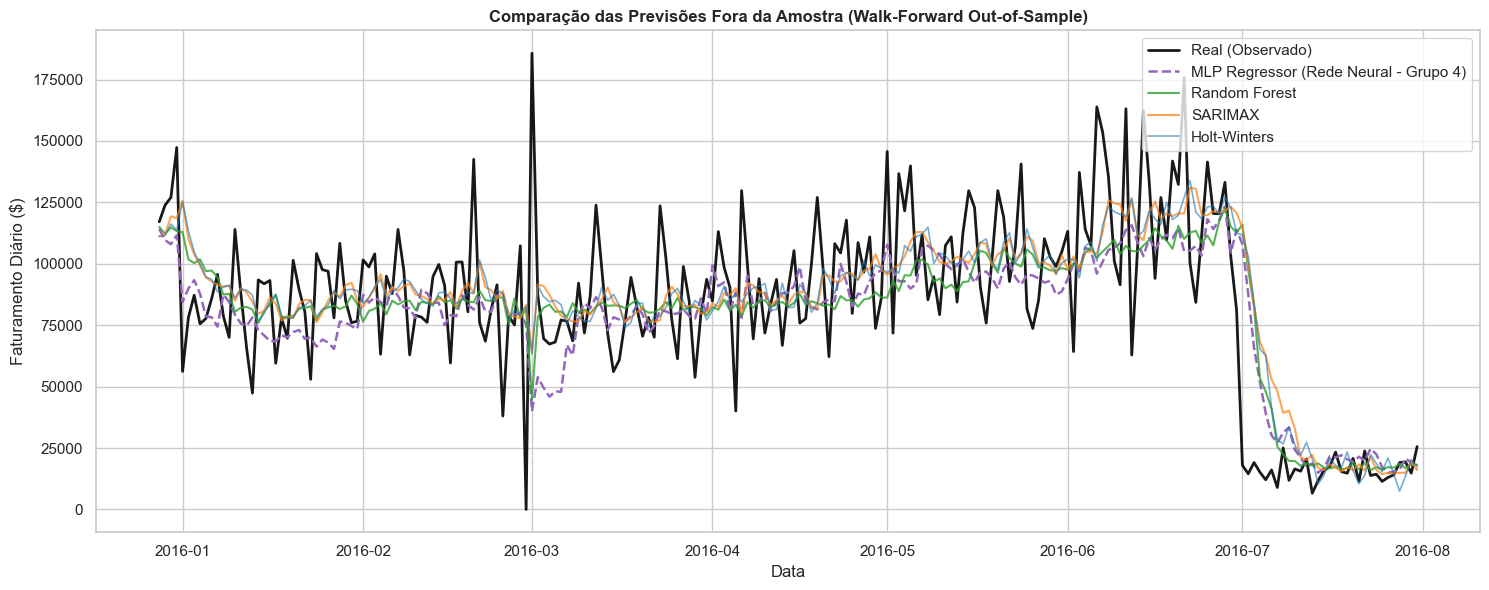


Arquivos salvos em ./resultados_bike_sales/ (para as 5 bases: concatene os mae_*.csv e use resumo_ranking).


,Posicao_media,Vitórias
Modelo,,
MLP Regressor (Rede Neural),1.00,1.00
Random Forest,2.00,0.00
Holt-Winters,3.00,0.00
SARIMAX,4.00,0.00


In [15]:
# Criação do DataFrame de Resultados Fora da Amostra
df_results = pd.DataFrame({'Data': test_dates, 'Real': y_true_list, **preds}).set_index('Data')

# Cálculo de Métricas Comparativas
models = model_names
familias = {'Holt-Winters': 'Univariado', 'SARIMAX': 'Estatístico Exógeno',
            'Random Forest': 'Ensemble Árvores', 'MLP Regressor (Rede Neural)': 'Rede Neural Artificial'}
metrics = []
total_actual = df_results['Real'].sum()

for m in models:
    mae = mean_absolute_error(df_results['Real'], df_results[m])
    rmse = np.sqrt(mean_squared_error(df_results['Real'], df_results[m]))
    wape = (np.sum(np.abs(df_results['Real'] - df_results[m])) / total_actual) * 100
    metrics.append({
        'Modelo': m,
        'Família': familias[m],
        'MAE ($)': mae,
        'RMSE ($)': rmse,
        'WAPE (%)': wape,
        'Tempo WF (s)': timers[m]
    })

df_metrics = pd.DataFrame(metrics).sort_values(by='MAE ($)').reset_index(drop=True)
df_metrics['Posição / Ranking'] = df_metrics.index + 1

print('=== TABELA COMPARATIVA DE DESEMPENHO (WALK-FORWARD) ===')
display(df_metrics[['Posição / Ranking', 'Modelo', 'Família', 'MAE ($)', 'RMSE ($)', 'WAPE (%)', 'Tempo WF (s)']])

# Referência: baselines no MESMO conjunto de teste
assert (df_results.index == y_test.index).all()
print('\n=== REFERÊNCIA: BASELINES NO MESMO CONJUNTO DE TESTE ===')
display(df_baselines.sort_values('MAE_test')[['Modelo', 'Parâmetro', 'MAE_test']])

# Visualização Gráfica Comparativa das Previsões
plt.figure(figsize=(15, 6))
plt.plot(df_results.index, df_results['Real'], label='Real (Observado)', color='black', lw=2, alpha=0.9)
plt.plot(df_results.index, df_results['MLP Regressor (Rede Neural)'], label='MLP Regressor (Rede Neural - Grupo 4)', color='#9467bd', lw=1.8, linestyle='--')
plt.plot(df_results.index, df_results['Random Forest'], label='Random Forest', color='#2ca02c', lw=1.5, alpha=0.8)
plt.plot(df_results.index, df_results['SARIMAX'], label='SARIMAX', color='#ff7f0e', lw=1.5, alpha=0.7)
plt.plot(df_results.index, df_results['Holt-Winters'], label='Holt-Winters', color='#1f77b4', lw=1.2, alpha=0.6)

plt.title('Comparação das Previsões Fora da Amostra (Walk-Forward Out-of-Sample)', fontweight='bold', fontsize=12)
plt.ylabel('Faturamento Diário ($)')
plt.xlabel('Data')
plt.legend(loc='upper right', frameon=True)
plt.tight_layout()
plt.show()

# ---- Arquivos de resultados (entrega): MAE consolidado, previsões e parâmetros ----
OUT_DIR = 'resultados_bike_sales'
os.makedirs(OUT_DIR, exist_ok=True)
df_metrics.assign(Base='Bike Sales').to_csv(f'{OUT_DIR}/mae_bike_sales.csv', index=False)
df_results.to_csv(f'{OUT_DIR}/previsoes_bike_sales.csv')

parametros = {
    'teste': {'inicio': str(TEST_START.date()), 'fim': str(test_df.index.max().date()), 'horizonte_dias': 1, 'reajuste_a_cada_dias': REFIT_EVERY},
    'holt_winters': best_hw_cfg,
    'sarimax': {'order': best_sarimax_order, 'seasonal_order': best_sarimax_seasonal, 'exogenas': sarimax_exog_cols, 'escala_alvo': SCALE},
    'random_forest': best_rf_params,
    'mlp': {**best_mlp_params, 'n_seeds': N_SEEDS, 'max_iter': 1000, 'alvo_padronizado': True},
    'tempo_execucao_s': timers
}
with open(f'{OUT_DIR}/parametros_bike_sales.json', 'w', encoding='utf-8') as f:
    json.dump(parametros, f, indent=2, ensure_ascii=False, default=lambda o: o.item() if hasattr(o, 'item') else str(o))

def resumo_ranking(df_all):
    """Vitórias e posição média por modelo. Recebe os CSVs de MAE das cinco bases concatenados."""
    d = df_all.copy()
    d['Posição'] = d.groupby('Base')['MAE ($)'].rank(method='min')
    vit = d[d['Posição'] == 1].groupby('Modelo').size().rename('Vitórias')
    res = d.groupby('Modelo').agg(Posicao_media=('Posição', 'mean')).join(vit).fillna({'Vitórias': 0})
    return res.sort_values('Posicao_media')

print(f'\nArquivos salvos em ./{OUT_DIR}/ (para as 5 bases: concatene os mae_*.csv e use resumo_ranking).')
display(resumo_ranking(pd.read_csv(f'{OUT_DIR}/mae_bike_sales.csv')))

## 16. Análise dos Resíduos e Teste de Ljung-Box

Os resíduos fora da amostra são definidos por $e_t = Y_t - \hat{Y}_t$. Para diagnosticar ruído branco e a qualidade dos ajustes:
1. **Gráficos dos Resíduos ao longo do tempo**.
2. **Função de Autocorrelação (ACF)** dos resíduos.
3. **Teste Estatístico de Ljung-Box** ($H_0$: os resíduos são ruído branco / não autocorrelacionados), nos lags 7 e 14. O resíduo só é considerado sem autocorrelação se **ambos** os p-valores forem > 0,05.
4. **Viés**: média dos resíduos e teste t ($H_0$: média zero). Resíduo não autocorrelacionado não implica bom modelo; um modelo pode ser enviesado ou ter erro grande com resíduos "brancos".

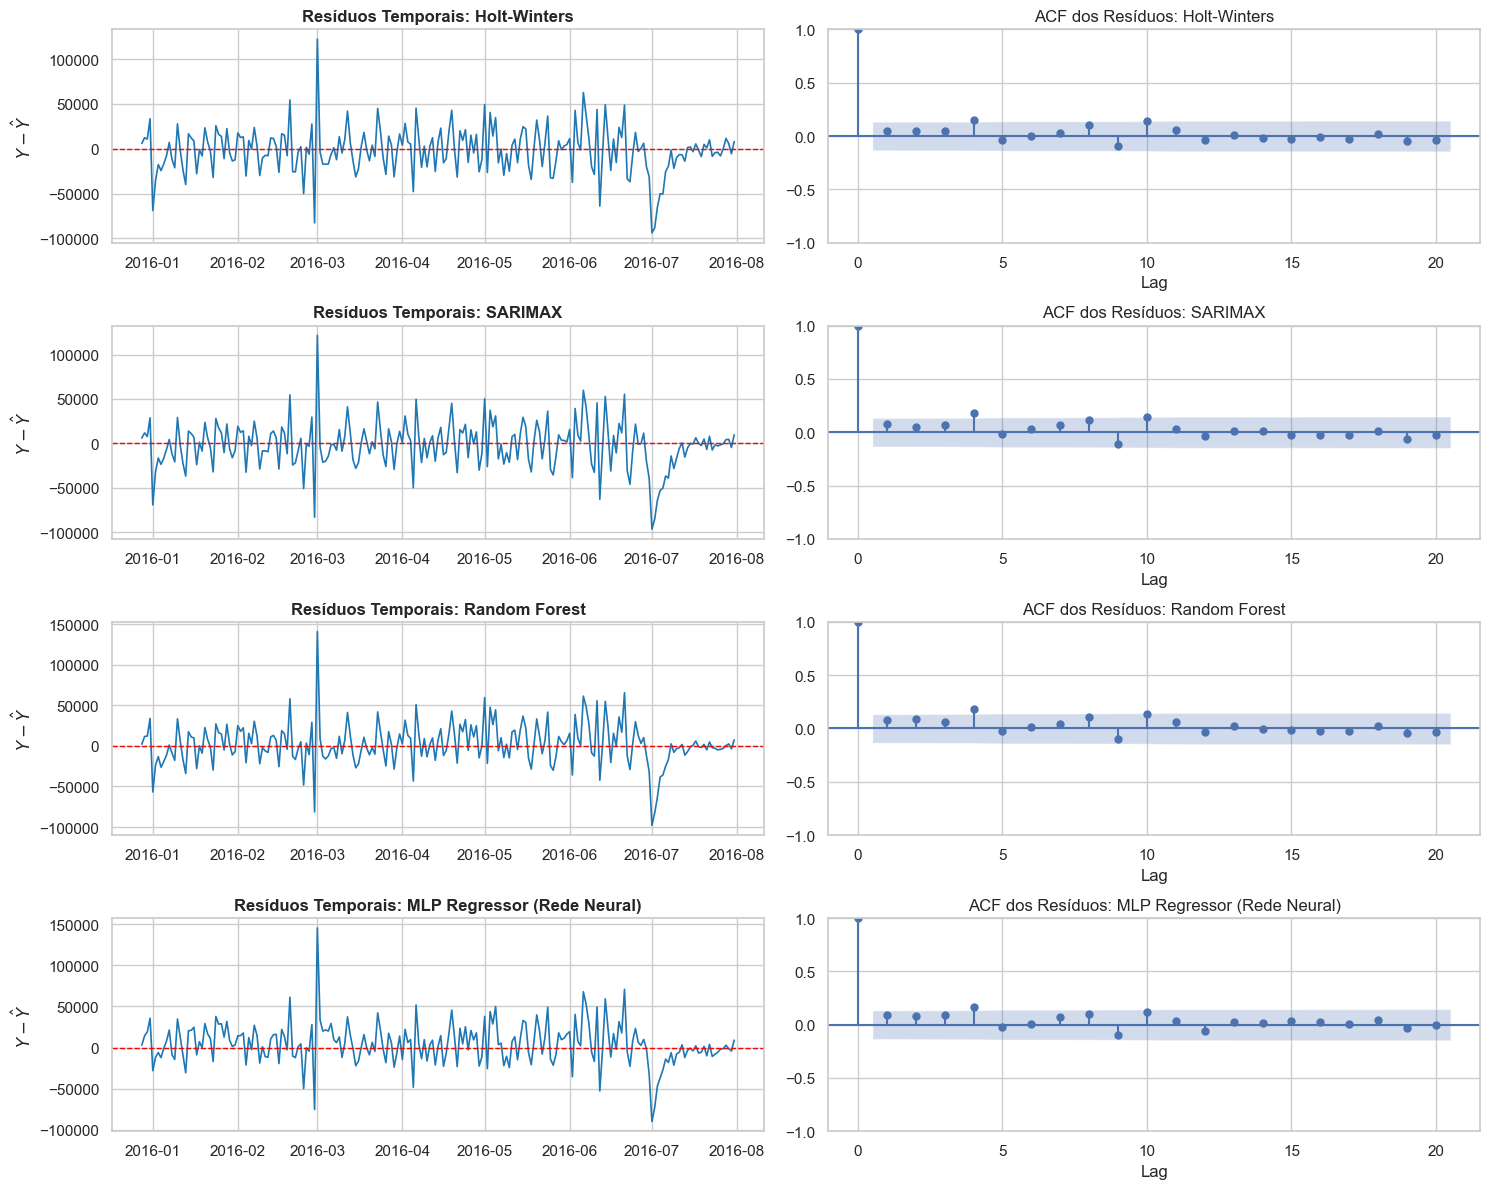

=== TABELA CONSOLIDADA DO TESTE DE LJUNG-BOX E VIÉS ===


,Modelo,Estatística LB (Lag 7),p-valor (Lag 7),Estatística LB (Lag 14),p-valor (Lag 14),Diagnóstico (Lags 7 e 14),Viés médio ($),p-valor (viés),Desvio-padrão ($)
0,Holt-Winters,7.0966,0.4189,17.1551,0.2480,Sem autocorr. sig. (Ruído Branco),-1913.3058,0.2810,26077.5233
1,SARIMAX,11.3509,0.1240,22.0346,0.0779,Sem autocorr. sig. (Ruído Branco),-2237.3894,0.2132,26398.3973
2,Random Forest,12.2861,0.0915,22.6733,0.0658,Sem autocorr. sig. (Ruído Branco),2256.9948,0.2043,26110.5198
3,MLP Regressor (Rede Neural),12.3448,0.0898,21.2498,0.0954,Sem autocorr. sig. (Ruído Branco),4629.0670,0.0078,25395.0219


In [16]:
# Cálculo dos Resíduos para todos os modelos
df_residuals = pd.DataFrame(index=df_results.index)
for m in models:
    df_residuals[m] = df_results['Real'] - df_results[m]
df_residuals.to_csv(f'{OUT_DIR}/residuos_bike_sales.csv')

# Plot dos Resíduos Temporais e ACF
fig, axes = plt.subplots(len(models), 2, figsize=(15, 12))

for idx, m in enumerate(models):
    axes[idx, 0].plot(df_residuals.index, df_residuals[m], lw=1.2, color='#1f77b4')
    axes[idx, 0].axhline(0, color='red', linestyle='--', lw=1)
    axes[idx, 0].set_title(f'Resíduos Temporais: {m}', fontweight='bold')
    axes[idx, 0].set_ylabel(r'$Y - \hat{Y}$')

    plot_acf(df_residuals[m].dropna(), lags=20, ax=axes[idx, 1], title=f'ACF dos Resíduos: {m}')
    axes[idx, 1].set_xlabel('Lag')

plt.tight_layout()
plt.show()

# Execução do Teste de Ljung-Box nos lags 7 e 14 + análise de viés
lb_rows = []
for m in models:
    res_m = df_residuals[m].dropna()
    lb_res = acorr_ljungbox(res_m, lags=[7, 14], return_df=True)
    t_stat, p_bias = stats.ttest_1samp(res_m, 0.0)
    ok7, ok14 = lb_res.loc[7, 'lb_pvalue'] > 0.05, lb_res.loc[14, 'lb_pvalue'] > 0.05
    lb_rows.append({
        'Modelo': m,
        'Estatística LB (Lag 7)': lb_res.loc[7, 'lb_stat'],
        'p-valor (Lag 7)': lb_res.loc[7, 'lb_pvalue'],
        'Estatística LB (Lag 14)': lb_res.loc[14, 'lb_stat'],
        'p-valor (Lag 14)': lb_res.loc[14, 'lb_pvalue'],
        'Diagnóstico (Lags 7 e 14)': 'Sem autocorr. sig. (Ruído Branco)' if (ok7 and ok14) else 'Autocorrelação Residual',
        'Viés médio ($)': res_m.mean(),
        'p-valor (viés)': p_bias,
        'Desvio-padrão ($)': res_m.std()
    })

df_ljungbox = pd.DataFrame(lb_rows)
print('=== TABELA CONSOLIDADA DO TESTE DE LJUNG-BOX E VIÉS ===')
with pd.option_context('display.float_format', '{:.4f}'.format):
    display(df_ljungbox)

## 17. Importância das Features e Interpretação

Analisamos a contribuição preditiva das variáveis nos modelos compatíveis. Para que a importância seja **realmente fora da amostra**, usamos os modelos **congelados no treino inicial** (antes de qualquer reajuste do walk-forward) e avaliamos no conjunto de teste:
- **MLP Regressor (Rede Neural)**: *Permutation Importance* (aumento do MAE ao embaralhar cada feature).
- **Random Forest**: importância nativa de impureza (*MDI*) e *Permutation Importance*.
- **Importância por grupo**: como lags e janelas móveis são fortemente correlacionados, permutamos grupos de features em conjunto (lags do alvo, janelas móveis, exógenas defasadas, calendário). Isso evita subestimar a importância de variáveis redundantes.
- **SARIMAX**: sinal, magnitude e significância ($p$-valor) dos coeficientes das exógenas (alvo e exógenas de valor em milhares de US$).

**Disponibilidade temporal das exógenas**: `cost_lag_*` e `qty_lag_*` usam apenas valores observados até $t-1$ (disponíveis na origem); as variáveis de calendário são conhecidas antecipadamente. Nenhuma exógena do próprio dia $t$ é utilizada.

=== IMPORTÂNCIA POR GRUPO DE FEATURES (fora da amostra) ===


,Grupo,MLP (aumento MAE $),Random Forest (aumento MAE $)
0,Lags do alvo,2482.80,1842.54
1,Janelas móveis do alvo,15374.09,10272.62
2,"Exógenas defasadas (Cost, Order_Quantity)",1206.16,1048.38
3,Calendário,1574.18,385.84


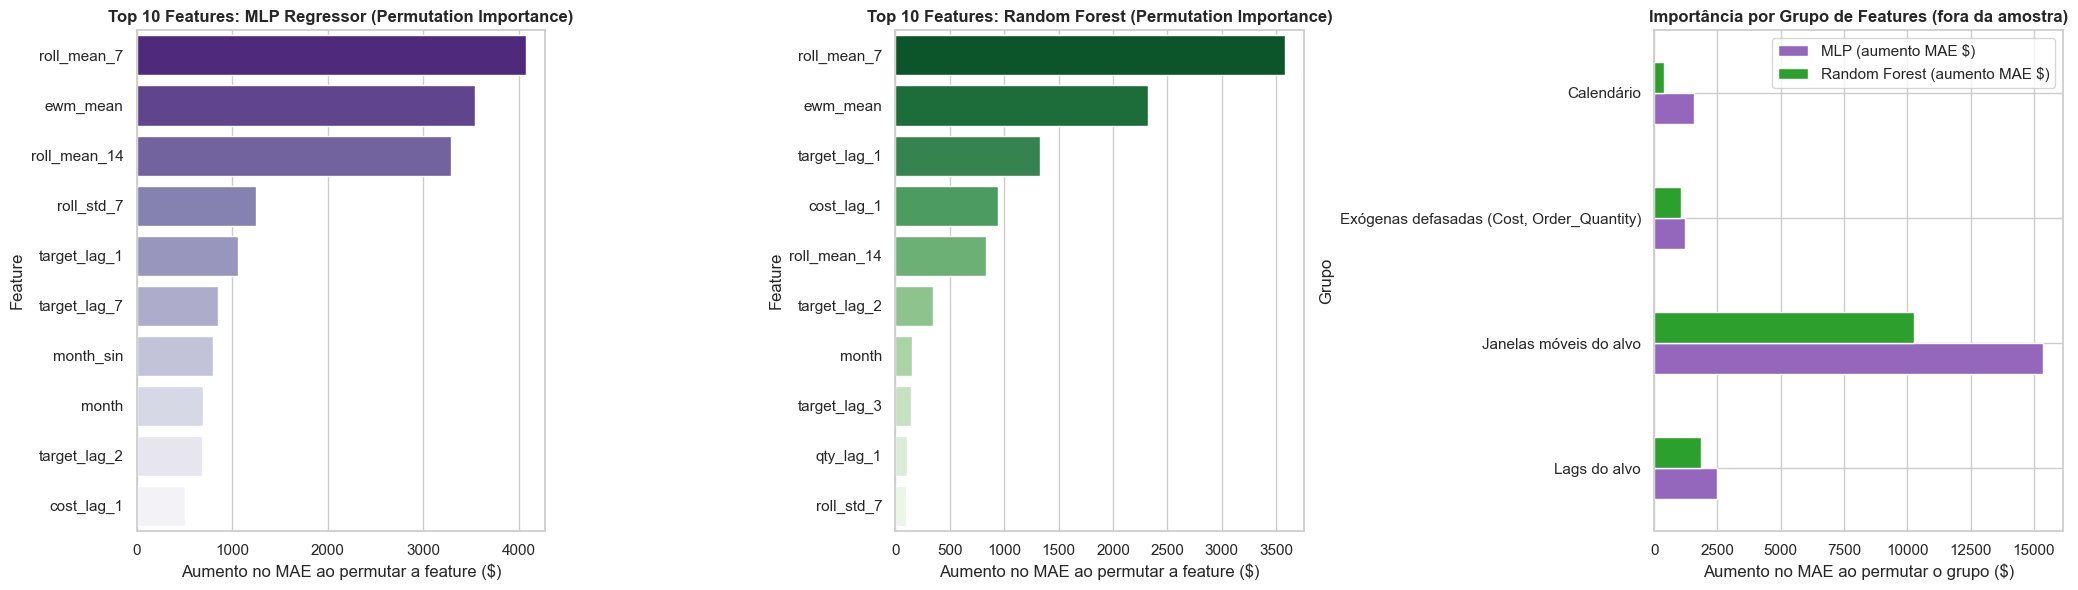

=== COEFICIENTES DAS VARIÁVEIS EXÓGENAS NO SARIMAX (alvo em milhares de US$) ===


,Variável Exógena,Coeficiente,p-valor,Disponível na origem?
0,dow_sin,-1.6062,0.2313,Sim (calendário)
1,dow_cos,-1.2930,0.1985,Sim (calendário)
2,is_weekend,1.1508,0.5014,Sim (calendário)
3,is_holiday_us,-1.8400,0.4692,Sim (calendário)
4,cost_lag_1,-0.7802,0.0004,Sim (lag t-1)
5,qty_lag_1,-1.2474,0.5576,Sim (lag t-1)


In [17]:
# Grupos de features (variáveis externas/derivadas destacadas)
feature_groups = {
    'Lags do alvo': [c for c in feature_columns if c.startswith('target_lag_')],
    'Janelas móveis do alvo': [c for c in feature_columns if c.startswith('roll_') or c == 'ewm_mean'],
    'Exógenas defasadas (Cost, Order_Quantity)': [c for c in feature_columns if c.startswith(('cost_lag_', 'qty_lag_'))],
    'Calendário': ['dayofweek', 'day', 'month', 'is_weekend', 'is_holiday_us', 'is_month_start', 'is_month_end',
                   'dow_sin', 'dow_cos', 'month_sin', 'month_cos']
}
assert sorted(sum(feature_groups.values(), [])) == sorted(feature_columns), 'Todo feature deve pertencer a um grupo.'

X_te, y_te = test_df[feature_columns], test_df['Revenue']

def grouped_permutation_importance(model, X, y, groups, n_repeats=10, seed=42):
    rng = np.random.RandomState(seed)
    base = mean_absolute_error(y, model.predict(X))
    out = {}
    for g, cols in groups.items():
        deltas = []
        for _ in range(n_repeats):
            Xp = X.copy()
            Xp[cols] = Xp[cols].values[rng.permutation(len(Xp))]
            deltas.append(mean_absolute_error(y, model.predict(Xp)) - base)
        out[g] = np.mean(deltas)
    return out

# 1. Permutation Importance no MLP Regressor (modelo congelado no treino, avaliado fora da amostra)
perm_mlp = permutation_importance(mlp_frozen, X_te, y_te, scoring='neg_mean_absolute_error', n_repeats=10, random_state=42)
df_perm_mlp = pd.DataFrame({
    'Feature': feature_columns,
    'Importance_MAE_Drop': perm_mlp.importances_mean
}).sort_values(by='Importance_MAE_Drop', ascending=False)

# 2. Permutation Importance e MDI no Random Forest
perm_rf = permutation_importance(rf_frozen, X_te, y_te, scoring='neg_mean_absolute_error', n_repeats=10, random_state=42)
df_perm_rf = pd.DataFrame({
    'Feature': feature_columns,
    'Importance_MAE_Drop': perm_rf.importances_mean,
    'MDI_Importance': rf_frozen.feature_importances_
}).sort_values(by='Importance_MAE_Drop', ascending=False)

# 3. Importância por grupo
gp_mlp = grouped_permutation_importance(mlp_frozen, X_te, y_te, feature_groups)
gp_rf = grouped_permutation_importance(rf_frozen, X_te, y_te, feature_groups)
df_group = pd.DataFrame({'Grupo': list(feature_groups), 'MLP (aumento MAE $)': list(gp_mlp.values()),
                         'Random Forest (aumento MAE $)': list(gp_rf.values())})
print('=== IMPORTÂNCIA POR GRUPO DE FEATURES (fora da amostra) ===')
display(df_group)

# Plot Comparativo de Importância das Features
fig, axes = plt.subplots(1, 3, figsize=(21, 6))

sns.barplot(data=df_perm_mlp.head(10), x='Importance_MAE_Drop', y='Feature', ax=axes[0], palette='Purples_r')
axes[0].set_title('Top 10 Features: MLP Regressor (Permutation Importance)', fontweight='bold')
axes[0].set_xlabel('Aumento no MAE ao permutar a feature ($)')

sns.barplot(data=df_perm_rf.head(10), x='Importance_MAE_Drop', y='Feature', ax=axes[1], palette='Greens_r')
axes[1].set_title('Top 10 Features: Random Forest (Permutation Importance)', fontweight='bold')
axes[1].set_xlabel('Aumento no MAE ao permutar a feature ($)')

df_group.set_index('Grupo').plot(kind='barh', ax=axes[2], color=['#9467bd', '#2ca02c'])
axes[2].set_title('Importância por Grupo de Features (fora da amostra)', fontweight='bold')
axes[2].set_xlabel('Aumento no MAE ao permutar o grupo ($)')

plt.tight_layout()
plt.show()

# Coeficientes do SARIMAX (modelo ajustado somente no treino inicial)
print('=== COEFICIENTES DAS VARIÁVEIS EXÓGENAS NO SARIMAX (alvo em milhares de US$) ===')
df_sarimax_coefs = pd.DataFrame({
    'Variável Exógena': sarimax_exog_cols,
    'Coeficiente': sarimax_frozen.params[sarimax_exog_cols].values,
    'p-valor': sarimax_frozen.pvalues[sarimax_exog_cols].values,
    'Disponível na origem?': ['Sim (calendário)'] * 4 + ['Sim (lag t-1)'] * 2
})
with pd.option_context('display.float_format', '{:.4f}'.format):
    display(df_sarimax_coefs)

## 18. Estudo Técnico e Didático do Modelo de Especialização: **MLP Regressor (Rede Neural Artificial)**

### 🧠 1. Intuição e Funcionamento do Algoritmo
O **Multilayer Perceptron (MLP)** é uma rede neural artificial *feedforward* composta por uma camada de entrada, camadas ocultas (*hidden layers*) de neurônios totalmente conectados (*dense layers*) e uma camada de saída contínua para regressão.

Para cada neurônio $j$ em uma camada oculta $l$, a ativação é dada por:
$$z_j^{[l]} = \sum_{i=1}^{n} w_{ji}^{[l]} a_i^{[l-1]} + b_j^{[l]}$$
$$a_j^{[l]} = f\left(z_j^{[l]}\right)$$
Onde:
- $w_{ji}$: Pesos sinápticos ajustáveis.
- $b_j$: Bias do neurônio.
- $f(\cdot)$: Função de ativação não linear (**ReLU** - *Rectified Linear Unit*: $f(z) = \max(0, z)$).

### ⚙️ 2. Aprendizado e Otimização (*Backpropagation* & Adam)
- **Forward Pass**: Os dados transformados passam pelas camadas gerando a previsão $\hat{Y}_t$.
- **Cálculo da Função de Perda com Regularização L2** (forma implementada no `scikit-learn`):
  $$\mathcal{L}(W) = \frac{1}{2N} \sum_{t=1}^N (Y_t - \hat{Y}_t)^2 + \frac{\alpha}{2N} \sum ||W||_2^2$$
- **Backward Pass (Backpropagation)**: Os gradientes parciais $\frac{\partial \mathcal{L}}{\partial W}$ são calculados via regra da cadeia e os pesos são atualizados pelo otimizador estocástico **Adam** (*Adaptive Moment Estimation*).

### 🎯 3. Papel dos Hiperparâmetros Chave
- `hidden_layer_sizes`: define a capacidade de abstração e combinação não linear de relações temporais e exógenas. Foi buscado entre `(32, 16)`, `(64, 32)`, `(100,)` e `(64,)`. Redes maiores capturam mais interações, mas aumentam o risco de *overfitting* com apenas ~900 amostras.
- `activation='relu'`: evita saturação e desvanecimento do gradiente (*vanishing gradient*).
- `alpha`: regularização $L_2$ (Ridge penalty) que penaliza pesos excessivos e previne *overfitting*; buscado entre 0,001 e 1,0.
- `learning_rate_init`: tamanho do passo inicial do Adam; passos grandes instabilizam, passos pequenos exigem mais iterações. Buscado entre 0,001 e 0,01.
- `max_iter=1000` e `early_stopping=False`: o `early_stopping` do `scikit-learn` usa uma validação **aleatória** (não temporal), inadequada para séries; o treino para por convergência da perda (`tol`).
- **Média de sementes**: a inicialização é aleatória, então o modelo final é a média de 5 redes treinadas com sementes diferentes, o que reduz a variância.

### 💡 4. Vantagens e Cuidados na Aplicação em Séries Temporais
- **Vantagens**: Capacidade de capturar interações não lineares complexas entre lags de receita, custos e sazonalidades cíclicas simultâneas.
- **Requisito Crítico**: **Sensibilidade à escala** — é mandatório padronizar as variáveis explicativas (`StandardScaler`) **e também o alvo** (`TransformedTargetRegressor`). Com o alvo na escala de $10^4$ a $10^5$ a rede subajusta e não converge, e as previsões voltam à escala original em US$ automaticamente.
- **Limitações**: pouca interpretabilidade (usa-se *Permutation Importance*) e sensibilidade à semente e à quantidade de dados.

=== ESTRUTURA DA REDE NEURAL (MLP REGRESSOR) TREINADA ===
Camadas Ocultas (Hidden Layers): (64,)
Função de Ativação: relu
Otimizador: adam
Regularização Alpha (L2): 1.0
Taxa de aprendizado inicial: 0.005
Redes na média (sementes): 5
Iterações por semente: [128, 94, 123, 124, 118] (limite max_iter=1000)
Convergência antes do limite de iterações: sim
Perda final média (alvo padronizado): 0.0794


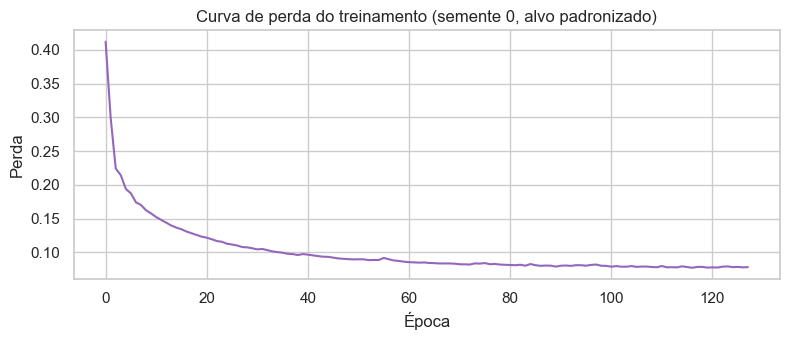

In [18]:
# Sumário da Arquitetura do Modelo de Especialização MLP (modelo congelado no treino inicial)
mlp_members = [mdl.regressor_.named_steps['mlp'] for mdl in mlp_frozen.models_]
mlp_engine = mlp_members[0]
print('=== ESTRUTURA DA REDE NEURAL (MLP REGRESSOR) TREINADA ===')
print(f'Camadas Ocultas (Hidden Layers): {mlp_engine.hidden_layer_sizes}')
print(f'Função de Ativação: {mlp_engine.activation}')
print(f'Otimizador: {mlp_engine.solver}')
print(f'Regularização Alpha (L2): {mlp_engine.alpha}')
print(f'Taxa de aprendizado inicial: {mlp_engine.learning_rate_init}')
print(f'Redes na média (sementes): {len(mlp_members)}')
print(f'Iterações por semente: {[m.n_iter_ for m in mlp_members]} (limite max_iter={mlp_engine.max_iter})')
convergiu = all(m.n_iter_ < m.max_iter for m in mlp_members)
print(f'Convergência antes do limite de iterações: {"sim" if convergiu else "NÃO - aumentar max_iter"}')
print(f'Perda final média (alvo padronizado): {np.mean([m.loss_ for m in mlp_members]):.4f}')

plt.figure(figsize=(8, 3.5))
plt.plot(mlp_engine.loss_curve_, color='#9467bd')
plt.title('Curva de perda do treinamento (semente 0, alvo padronizado)')
plt.xlabel('Época')
plt.ylabel('Perda')
plt.tight_layout()
plt.show()